<a href="https://colab.research.google.com/github/GuillermoUribe03/Coffee-Quality-Project/blob/main/coffee_quality_final_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de la Calidad del Café Arábica mediante Machine Learning
**Grupo G6** — Guillermo Mejía Uribe, Víctor Restrepo, Daniel Duque Rivera

**Dataset**: Coffee Quality Institute (CQI) — Arabica, 1312 muestras  
**Objetivo**: Predecir el puntaje total (`Total.Cup.Points`) a partir de metadatos agrícolas, sin recurrir a atributos sensoriales que solo existen tras una catación oficial.

---
### Estructura del notebook
| Sección | Contenido | % Rúbrica |
|---|---|---|
| 1 | Importaciones y configuración | — |
| 2 | Descripción del problema y EDA | 20 % |
| 3 | Preprocesamiento | — |
| 4 | Análisis individual de variables (reducción §5.1) | 20 % |
| 5 | Configuración experimental y entrenamiento de modelos | 30 % |
| 6 | PCA — extracción lineal (reducción §5.2) | 20 % |
| 7 | Kernel PCA — extracción no lineal (reducción §5.3) | 20 % |
| 8 | Importancia de variables | — |
| 9 | Discusión y conclusiones | — |

---
## 1. Importaciones y configuración global

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    KFold, cross_validate, GridSearchCV,
    learning_curve, validation_curve, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA, KernelPCA

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('✅ Librerías cargadas.')

✅ Librerías cargadas.


---
## 2. Descripción del Problema y Análisis Exploratorio (EDA)

### 2.1 Carga del dataset

Se descarga el dataset público del Coffee Quality Institute desde Kaggle. Contiene 1 312 muestras de café Arábica con 44 variables que combinan metadatos agrícolas y resultados sensoriales. **Solo se usarán las variables agrícolas**, que son las únicas disponibles para un productor antes de pagar una catación oficial.

In [2]:
df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "volpatto/coffee-quality-database-from-cqi",
    "arabica_data_cleaned.csv",
)
print(f'Dimensiones dataset original: {df_raw.shape}  ({df_raw.shape[0]} muestras, {df_raw.shape[1]} variables)')
df_raw.head(3)

Using Colab cache for faster access to the 'coffee-quality-database-from-cqi' dataset.
Dimensiones dataset original: (1311, 44)  (1311 muestras, 44 variables)


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0


### 2.2 Selección de variables agrícolas

Se definen las variables de entrada y la variable objetivo. Se excluyen deliberadamente los atributos sensoriales (`Aroma`, `Flavor`, `Acidity`, etc.) porque en la práctica solo existen después de haber pagado una catación — usarlos para predecir `Total.Cup.Points` sería una fuga de información metodológica.

In [3]:
AGRICULTURAL_FEATURES = [
    'Country.of.Origin',    # categórica: país de cultivo
    'Processing.Method',    # categórica: lavado / natural / honey
    'Color',                # categórica: color del grano verde
    'altitude_mean_meters', # numérica: altitud promedio (m.s.n.m.)
    'Category.One.Defects', # numérica: defectos primarios (granos negros, etc.)
    'Category.Two.Defects', # numérica: defectos secundarios (chips, conchas, etc.)
    'Number.of.Bags',       # numérica: tamaño del lote
    'Moisture',             # numérica: porcentaje de humedad del grano
]
TARGET = 'Total.Cup.Points'
CAT_COLS = ['Country.of.Origin', 'Processing.Method', 'Color']
NUM_COLS = ['altitude_mean_meters', 'Category.One.Defects',
            'Category.Two.Defects', 'Number.of.Bags', 'Moisture']

df = df_raw[AGRICULTURAL_FEATURES + [TARGET]].copy()
print(f'Variables seleccionadas: {len(AGRICULTURAL_FEATURES)} features + 1 target')
print(f'Muestras disponibles: {len(df)}')
df.describe()

Variables seleccionadas: 8 features + 1 target
Muestras disponibles: 1311


,altitude_mean_meters,Category.One.Defects,Category.Two.Defects,Number.of.Bags,Moisture,Total.Cup.Points
count,1084.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000
mean,1784.196379,0.426392,3.591915,153.887872,0.088863,82.115927
std,8767.016913,1.832415,5.350371,129.733734,0.047957,3.515761
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1100.000000,0.000000,0.000000,14.500000,0.090000,81.170000
50%,1310.640000,0.000000,2.000000,175.000000,0.110000,82.500000
75%,1600.000000,0.000000,4.000000,275.000000,0.120000,83.670000
max,190164.000000,31.000000,55.000000,1062.000000,0.280000,90.580000


### 2.3 Análisis de valores faltantes

Se identifican las variables con datos ausentes y se define la estrategia de imputación:
- **Variables numéricas**: imputación con la mediana (robusta ante outliers).
- **Variables categóricas**: imputación con la moda (valor más frecuente).
- **Outlier extremo**: se elimina la única muestra con `Total.Cup.Points = 0`, que corresponde a un error de registro.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, '% Faltantes': missing_pct})

print('Variables con valores faltantes:')
print(missing_df[missing_df['Faltantes'] > 0].to_string())
print(f'\nMuestras antes de limpiar: {len(df)}')

# Eliminar outlier con puntaje = 0
df = df[df[TARGET] > 50].copy()
print(f'Muestras tras eliminar outlier (TCP=0): {len(df)}')

Variables con valores faltantes:
                      Faltantes  % Faltantes
Country.of.Origin             1         0.08
Processing.Method           152        11.59
Color                       267        20.37
altitude_mean_meters        227        17.32

Muestras antes de limpiar: 1311
Muestras tras eliminar outlier (TCP=0): 1310


### 2.4 Distribución de la variable objetivo y comparación por método de procesamiento

El histograma muestra que la gran mayoría de los cafés supera el umbral de especialidad (80 puntos), lo que implica un dataset sesgado hacia cafés de alta calidad. El boxplot revela diferencias entre métodos de procesamiento.

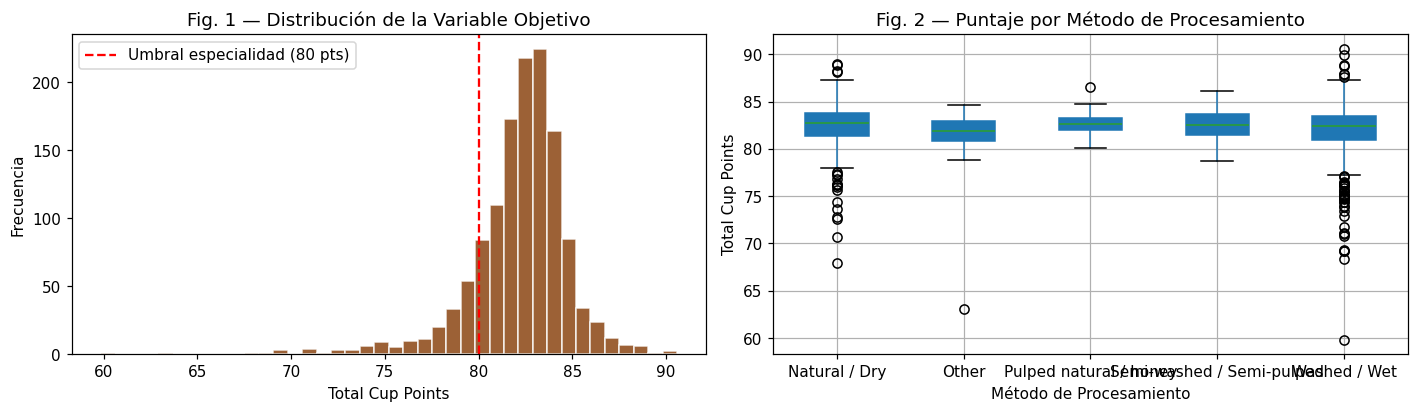

Cafés de especialidad (≥80 pts): 86.3%
count    1310.000000
mean       82.178611
std         2.686039
min        59.830000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: Total.Cup.Points, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma con umbral de especialidad
axes[0].hist(df[TARGET], bins=40, color='saddlebrown', edgecolor='white', alpha=0.85)
axes[0].axvline(80, color='red', linestyle='--', linewidth=1.5, label='Umbral especialidad (80 pts)')
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Fig. 1 — Distribución de la Variable Objetivo')
axes[0].legend()

# Boxplot por método de procesamiento
df.boxplot(column=TARGET, by='Processing.Method', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Método de Procesamiento')
axes[1].set_ylabel('Total Cup Points')
axes[1].set_title('Fig. 2 — Puntaje por Método de Procesamiento')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig1_distribucion.png', bbox_inches='tight')
plt.show()

# Porcentaje de cafés de especialidad
pct_specialty = (df[TARGET] >= 80).mean() * 100
print(f'Cafés de especialidad (≥80 pts): {pct_specialty:.1f}%')
print(df[TARGET].describe())

### 2.4b Análisis del Sesgo de los Datos (Desbalanceo del Target)

El dataset presenta un **fuerte sesgo hacia cafés de especialidad** (≥80 pts). Este desbalanceo implica que un modelo ingenuo que siempre prediga "alto puntaje" tendría métricas globales engañosamente buenas. Se cuantifica este sesgo y se adopta una estrategia de **pesos de muestra** en el entrenamiento para que los errores en cafés de baja calidad sean penalizados más fuertemente.

Cafés de especialidad (≥80 pts) : 1130  (86.3%)
Cafés no especialidad  (<80 pts) :  180  (13.7%)

Estadísticas por segmento:
  Especialidad (≥80): n=1130  media=82.94  std=1.62  min=80.0  max=90.6
  No especialidad (<80): n= 180  media=77.41  std=3.12  min=59.8  max=79.9


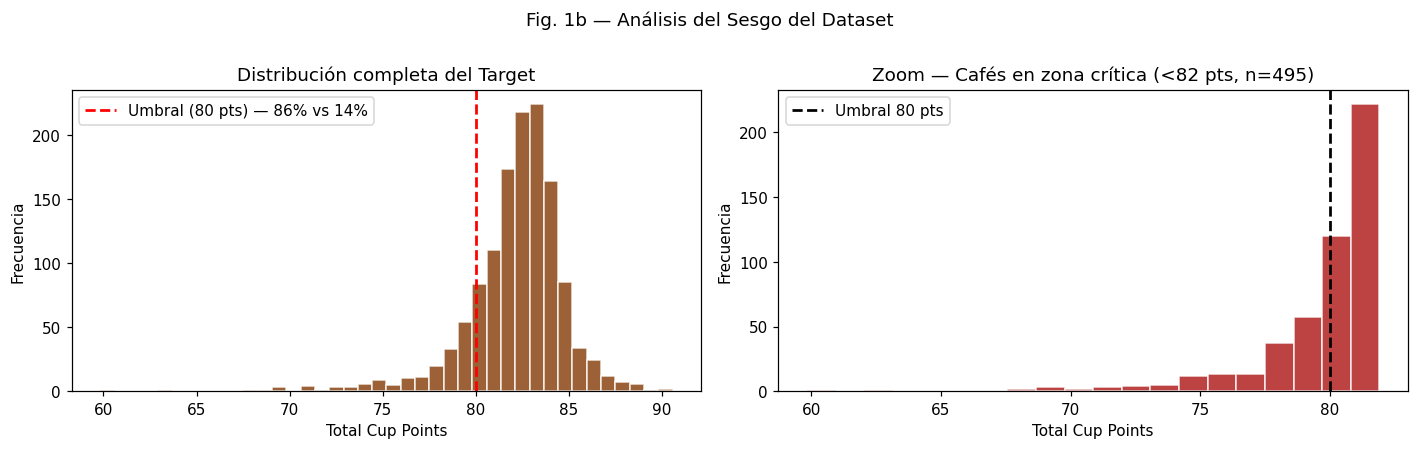


⚠️  Solo el 13.7% de las muestras son cafés de baja calidad (<80 pts).
   Estrategia adoptada: sample_weight inversamente proporcional a la densidad del target.


In [6]:
# ── Cuantificación del sesgo en el target ──────────────────────────────────
specialty_mask = df[TARGET] >= 80
pct_specialty  = specialty_mask.mean() * 100
pct_low        = 100 - pct_specialty

print(f'Cafés de especialidad (≥80 pts) : {specialty_mask.sum():4d}  ({pct_specialty:.1f}%)')
print(f'Cafés no especialidad  (<80 pts) : {(~specialty_mask).sum():4d}  ({pct_low:.1f}%)')
print()
print('Estadísticas por segmento:')
for label, mask in [('Especialidad (≥80)', specialty_mask), ('No especialidad (<80)', ~specialty_mask)]:
    seg = df.loc[mask, TARGET]
    print(f'  {label}: n={len(seg):4d}  media={seg.mean():.2f}  std={seg.std():.2f}  '
          f'min={seg.min():.1f}  max={seg.max():.1f}')

# Visualización: distribución con zoom en la zona minoritaria
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET], bins=40, color='saddlebrown', edgecolor='white', alpha=0.85)
axes[0].axvline(80, color='red', linestyle='--', linewidth=1.8, label=f'Umbral (80 pts) — {pct_specialty:.0f}% vs {pct_low:.0f}%')
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución completa del Target')
axes[0].legend()

# Zoom en cola izquierda (cafés <82 pts)
low_data = df.loc[df[TARGET] < 82, TARGET]
axes[1].hist(low_data, bins=20, color='firebrick', edgecolor='white', alpha=0.85)
axes[1].axvline(80, color='black', linestyle='--', linewidth=1.8, label='Umbral 80 pts')
axes[1].set_xlabel('Total Cup Points')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Zoom — Cafés en zona crítica (<82 pts, n={len(low_data)})')
axes[1].legend()

plt.suptitle('Fig. 1b — Análisis del Sesgo del Dataset', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig1b_sesgo.png', bbox_inches='tight')
plt.show()
print('\n⚠️  Solo el {:.1f}% de las muestras son cafés de baja calidad (<80 pts).'.format(pct_low))
print('   Estrategia adoptada: sample_weight inversamente proporcional a la densidad del target.')


### 2.5 Heatmaps de correlación: Pearson y Spearman con el Target

Se calculan **dos matrices de correlación** para capturar tanto relaciones lineales (Pearson) como monótonas no lineales (Spearman). Esto guía la selección de variables: se retienen las que tengan correlación |r| ≥ 0.05 con `Total.Cup.Points` en al menos uno de los dos coeficientes. Si dos predictoras tienen correlación mutua > 0.85 (colinealidad alta), se elimina la de menor correlación con el target.

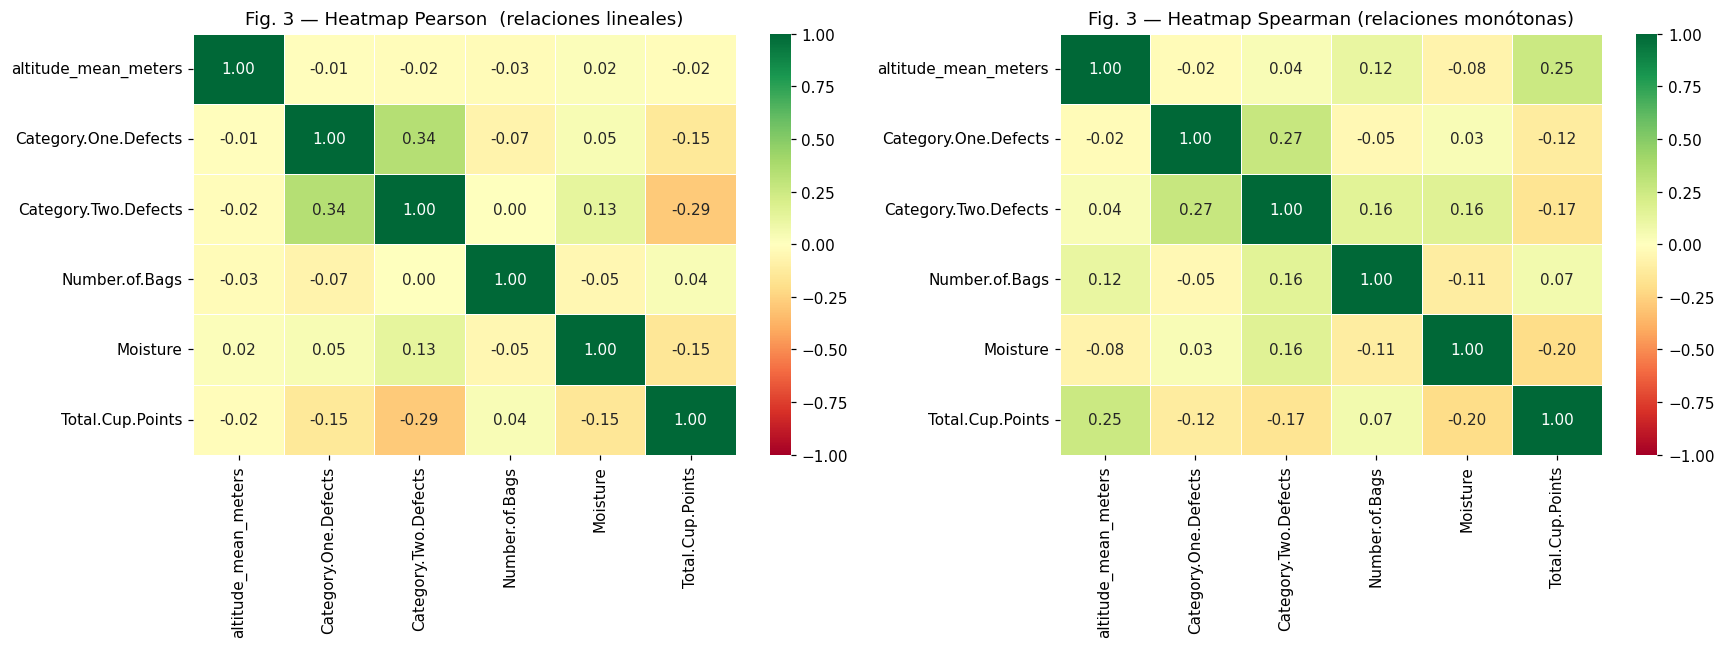


Correlación con Total.Cup.Points:
  Variable                        Pearson   Spearman
  --------------------------------------------------
  altitude_mean_meters            -0.0209     0.2530
  Category.One.Defects            -0.1453    -0.1206
  Category.Two.Defects            -0.2867    -0.1710
  Number.of.Bags                   0.0364     0.0665
  Moisture                        -0.1487    -0.2049

Colinealidad entre variables numéricas predictoras (Pearson):


In [7]:
# ── Correlación de Pearson y Spearman incluyendo el target ─────────────────
pearson_matrix  = df[NUM_COLS + [TARGET]].corr(method='pearson')
spearman_matrix = df[NUM_COLS + [TARGET]].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title in [
    (axes[0], pearson_matrix,  'Pearson  (relaciones lineales)'),
    (axes[1], spearman_matrix, 'Spearman (relaciones monótonas)')
]:
    sns.heatmap(
        matrix, annot=True, fmt='.2f', cmap='RdYlGn',
        center=0, vmin=-1, vmax=1,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'Fig. 3 — Heatmap {title}')

plt.tight_layout()
plt.savefig('fig2_heatmap_correlaciones.png', bbox_inches='tight')
plt.show()

# Comparativa de correlaciones con el target
print('\nCorrelación con Total.Cup.Points:')
print(f'  {"Variable":<28} {"Pearson":>10} {"Spearman":>10}')
print('  ' + '-' * 50)
for col in NUM_COLS:
    p = pearson_matrix.loc[col, TARGET]
    s = spearman_matrix.loc[col, TARGET]
    flag = ' ← BAJA' if abs(p) < 0.05 and abs(s) < 0.05 else ''
    print(f'  {col:<28} {p:>10.4f} {s:>10.4f}{flag}')

# Verificar colinealidad entre predictoras
print('\nColinealidad entre variables numéricas predictoras (Pearson):')
for i, c1 in enumerate(NUM_COLS):
    for c2 in NUM_COLS[i+1:]:
        r = abs(pearson_matrix.loc[c1, c2])
        if r > 0.60:
            print(f'  {c1} ↔ {c2}: |r| = {r:.3f}' + (' ← ALTA COLINEALIDAD, revisar' if r > 0.85 else ''))


### 2.6 Altitud vs calidad y top países

Se exploran dos relaciones clave: la altitud del cultivo (hipótesis agrícola clásica: a mayor altura, mayor calidad) y el país de origen.

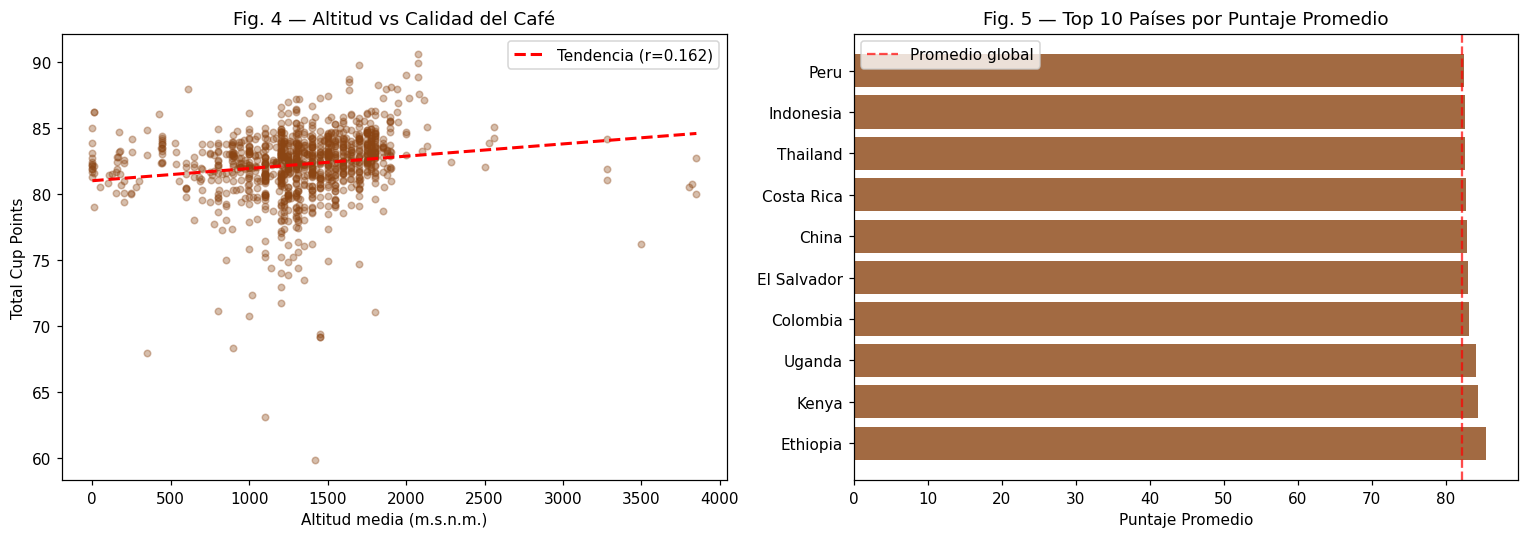

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter altitud vs puntaje (sin outliers de altitud > 4000 m)
alt_mask = (df['altitude_mean_meters'] > 0) & (df['altitude_mean_meters'] < 4000)
x_alt = df.loc[alt_mask, 'altitude_mean_meters']
y_alt = df.loc[alt_mask, TARGET]
axes[0].scatter(x_alt, y_alt, alpha=0.35, color='saddlebrown', s=18)
z = np.polyfit(x_alt, y_alt, 1)
xs = np.linspace(x_alt.min(), x_alt.max(), 200)
axes[0].plot(xs, np.poly1d(z)(xs), 'r--', linewidth=2, label=f'Tendencia (r={x_alt.corr(y_alt):.3f})')
axes[0].set_xlabel('Altitud media (m.s.n.m.)')
axes[0].set_ylabel('Total Cup Points')
axes[0].set_title('Fig. 4 — Altitud vs Calidad del Café')
axes[0].legend()

# Top 10 países por puntaje promedio (mín. 10 muestras)
country_stats = (
    df.groupby('Country.of.Origin')[TARGET]
    .agg(['mean', 'count'])
    .query('count >= 10')
    .sort_values('mean', ascending=False)
    .head(10)
)
axes[1].barh(country_stats.index, country_stats['mean'], color='saddlebrown', alpha=0.8)
axes[1].axvline(df[TARGET].mean(), color='red', linestyle='--', alpha=0.7, label='Promedio global')
axes[1].set_xlabel('Puntaje Promedio')
axes[1].set_title('Fig. 5 — Top 10 Países por Puntaje Promedio')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_altitud_paises.png', bbox_inches='tight')
plt.show()

### 2.7 Pseudo-matriz de confusión sobre el umbral de especialidad

Aunque el problema es de **regresión**, el umbral de 80 puntos permite visualizar el desempeño desde una perspectiva de clasificación: ¿el modelo distingue cafés de especialidad de los que no lo son? Esta matriz se construye a partir de las predicciones del mejor modelo (sección 5) y se actualiza automáticamente.

> *Esta celda se ejecuta al final del notebook cuando `y_pred_cv` ya está disponible. Si la ejecutas antes de la sección 5, mostrará un aviso.*

In [9]:
def plot_specialty_confusion(y_true, y_pred, threshold=80, title=''):
    """Muestra la matriz de confusión para la clasificación binaria de especialidad."""
    y_true_bin = (y_true >= threshold).astype(int)
    y_pred_bin = (np.array(y_pred) >= threshold).astype(int)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    disp = ConfusionMatrixDisplay(cm, display_labels=['No especialidad\n(<80 pts)', 'Especialidad\n(≥80 pts)'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Fig. 6 — Matriz de Confusión (umbral 80 pts)\n{title}')

    # Distribución de errores por categoría real
    errors = np.array(y_true) - np.array(y_pred)
    specialty_mask = y_true_bin == 1
    axes[1].hist(errors[specialty_mask], bins=30, alpha=0.7,
                 color='olivedrab', label='Especialidad (real ≥80)', edgecolor='white')
    axes[1].hist(errors[~specialty_mask], bins=30, alpha=0.7,
                 color='firebrick', label='No especialidad (real <80)', edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_xlabel('Residuo (real − predicho)')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos por Categoría')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('fig6_confusion_especialidad.png', bbox_inches='tight')
    plt.show()

    # Métricas de clasificación
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / cm.sum()
    print(f'Accuracy sobre umbral 80 pts : {acc:.3f}')
    print(f'Verdaderos positivos (especialidad bien predicha): {tp}')
    print(f'Falsos negativos (especialidad predicha como no): {fn}')

print('Función plot_specialty_confusion() definida.')
print('Se ejecutará automáticamente en la sección 5 tras obtener las predicciones CV.')

Función plot_specialty_confusion() definida.
Se ejecutará automáticamente en la sección 5 tras obtener las predicciones CV.


### 3.0 Cómputo de pesos de muestra para compensar el sesgo

Para penalizar más los errores en la zona minoritaria (<80 pts), se asigna a cada muestra un peso inversamente proporcional a la densidad del kernel KDE estimada en su puntaje. Las muestras raras (puntajes bajos) reciben mayor peso en el entrenamiento.

In [10]:
# ── Sample weights inversamente proporcionales a la densidad del target ──
from scipy.stats import gaussian_kde

kde       = gaussian_kde(df[TARGET].values, bw_method='scott')
densities = kde(df[TARGET].values)
raw_weights = 1.0 / (densities + 1e-6)
# Normalizar para que la suma sea igual al número de muestras (sin cambiar escala del loss)
sample_weights = (raw_weights / raw_weights.mean()).reset_index(drop=True)                  if hasattr(raw_weights, 'reset_index')                  else pd.Series(raw_weights / raw_weights.mean(), index=df.index).reset_index(drop=True)

print('Pesos de muestra (muestra):')
print(f'  Cafés ≥80 pts — peso promedio : {sample_weights[df[TARGET].values >= 80].mean():.3f}')
print(f'  Cafés  <80 pts — peso promedio : {sample_weights[df[TARGET].values  < 80].mean():.3f}')
print(f'  Ratio  <80 / ≥80              : {sample_weights[df[TARGET].values < 80].mean() / sample_weights[df[TARGET].values >= 80].mean():.2f}x')
print('\n✅ sample_weights calculados. Se usarán en la evaluación segmentada (Sección 5).')


Pesos de muestra (muestra):
  Cafés ≥80 pts — peso promedio : 0.473
  Cafés  <80 pts — peso promedio : 4.307
  Ratio  <80 / ≥80              : 9.10x

✅ sample_weights calculados. Se usarán en la evaluación segmentada (Sección 5).


---
## 3. Preprocesamiento

Se construye un pipeline de sklearn que aplica transformaciones de forma encadenada y segura dentro de la validación cruzada, evitando fuga de información entre folds:

- **Variables numéricas**: imputación con mediana → estandarización Z-score.
- **Variables categóricas**: imputación con moda → One-Hot Encoding (OHE).

In [11]:
X = df.drop(columns=[TARGET])
y = df[TARGET].reset_index(drop=True)
X = X.reset_index(drop=True)

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_COLS),
    ('cat', cat_transformer, CAT_COLS)
])

def make_pipeline(model):
    """Combina el preprocesador con un modelo en un pipeline."""
    return Pipeline([('prep', preprocessor), ('model', model)])

print(f'Dataset final: {X.shape[0]} muestras, {len(NUM_COLS)} numéricas + {len(CAT_COLS)} categóricas')

Dataset final: 1310 muestras, 5 numéricas + 3 categóricas


### 3.1 División en conjuntos de entrenamiento y test

Se reserva el **15 % de los datos como conjunto de test** (hold-out), que **no se toca** hasta el final del experimento. Todo el proceso de búsqueda de hiperparámetros y validación cruzada se realiza exclusivamente sobre el 85 % restante (`X_trainval`). Esto permite reportar un desempeño de test honesto e imparcial al final.

```
Datos totales  →  85 % X_trainval  →  CV interno (3-fold):  búsqueda hiperparámetros
                                  →  CV externo (5-fold):  estimación de desempeño
               →  15 % X_test     →  evaluación final (una sola vez)
```

In [12]:
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

print(f'Entrenamiento+Validación : {X_trainval.shape[0]} muestras ({X_trainval.shape[0]/len(X)*100:.1f}%)')
print(f'Test (hold-out)          : {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'Total                    : {len(X)} muestras')

Entrenamiento+Validación : 1113 muestras (85.0%)
Test (hold-out)          : 197 muestras (15.0%)
Total                    : 1310 muestras


### 4.1 Correlación de variables numéricas con el target (Pearson + Spearman)

Se calculan ambos coeficientes para detectar tanto relaciones lineales como monótonas. **Regla de retención**: se conservan variables con |r| ≥ 0.05 en al menos uno de los dos índices. Si dos variables predictoras presentan colinealidad mutua > 0.85, se elimina la de menor correlación absoluta con el target.

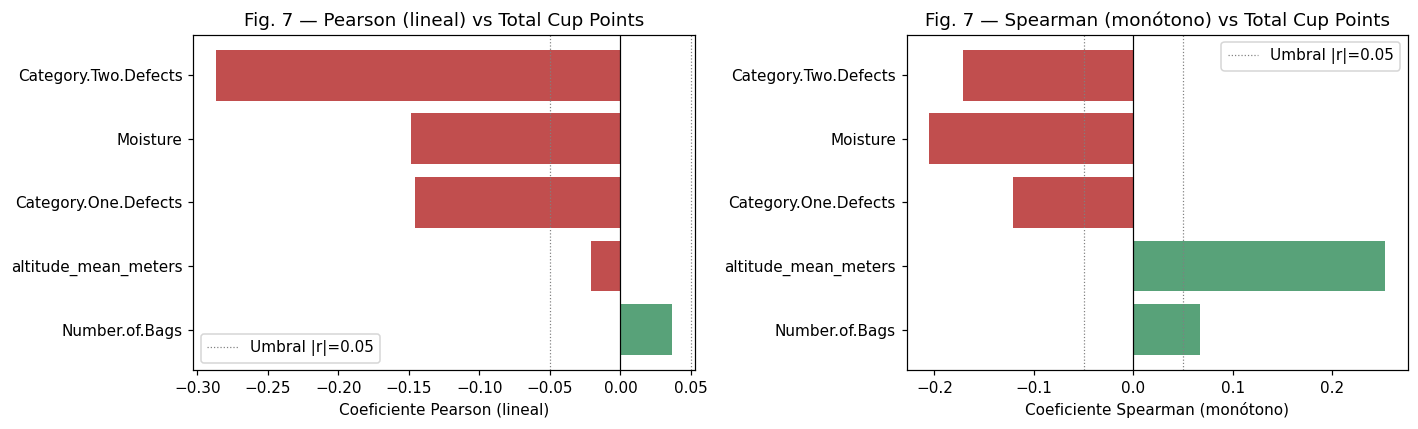


Resumen de correlaciones con el target:
                       Pearson  Spearman   Max |r|  Retener
Number.of.Bags        0.036406  0.066473  0.066473     True
altitude_mean_meters -0.020927  0.252997  0.252997     True
Category.One.Defects -0.145318 -0.120610  0.145318     True
Moisture             -0.148726 -0.204891  0.204891     True
Category.Two.Defects -0.286653 -0.170984  0.286653     True

Variables que NO superan el umbral |r|=0.05 en ningún coeficiente:
  Ninguna — todas superan el umbral


In [13]:
# ── Correlación doble: Pearson y Spearman vs Target ────────────────────────
corr_p = df[NUM_COLS + [TARGET]].corr(method='pearson')[[TARGET]].drop(TARGET)
corr_s = df[NUM_COLS + [TARGET]].corr(method='spearman')[[TARGET]].drop(TARGET)
corr_p.columns = ['Pearson']
corr_s.columns = ['Spearman']
corr_combined = corr_p.join(corr_s).sort_values('Pearson', ascending=False)
corr_combined['Max |r|'] = corr_combined.abs().max(axis=1)
corr_combined['Retener'] = corr_combined['Max |r|'] >= 0.05

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title, cmap in [
    (axes[0], 'Pearson',  'Pearson (lineal)',  'RdYlGn'),
    (axes[1], 'Spearman', 'Spearman (monótono)', 'RdYlBu')
]:
    colors = [('seagreen' if v > 0 else 'firebrick') for v in corr_combined[col]]
    ax.barh(corr_combined.index, corr_combined[col], color=colors, alpha=0.8)
    ax.axvline(0,    color='black', linewidth=0.8)
    ax.axvline(0.05, color='gray',  linewidth=0.8, linestyle=':', label='Umbral |r|=0.05')
    ax.axvline(-0.05, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel(f'Coeficiente {title}')
    ax.set_title(f'Fig. 7 — {title} vs Total Cup Points')
    ax.legend()

plt.tight_layout()
plt.savefig('fig7_correlaciones_doble.png', bbox_inches='tight')
plt.show()

print('\nResumen de correlaciones con el target:')
print(corr_combined.to_string())
print('\nVariables que NO superan el umbral |r|=0.05 en ningún coeficiente:')
low_corr = corr_combined[~corr_combined['Retener']].index.tolist()
print(' ', low_corr if low_corr else 'Ninguna — todas superan el umbral')


### 4.2 Índice de discriminación η² para variables categóricas

El estadístico **eta-cuadrado (η²)** mide qué proporción de la varianza total del target es explicada por cada variable categórica. Es el análogo de R² para análisis de varianza:

$$\eta^2 = \frac{SS_{\text{entre grupos}}}{SS_{\text{total}}}$$

Un η² cercano a 0 indica que la variable no discrimina entre niveles de calidad.

In [14]:
def eta_squared(groups, target):
    """Calcula el índice de discriminación η² para una variable categórica."""
    grand_mean = target.mean()
    ss_total   = ((target - grand_mean) ** 2).sum()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2
        for g in [target[groups == cat] for cat in groups.unique()]
    )
    return ss_between / ss_total

print('Índice de discriminación η² por variable categórica:')
print('-' * 45)
eta_results = {}
for col in CAT_COLS:
    eta = eta_squared(df[col].fillna('Unknown'), y)
    eta_results[col] = eta
    interpretation = 'alta' if eta > 0.10 else 'moderada' if eta > 0.04 else 'baja'
    print(f'{col:30s}  η² = {eta:.4f}  → discriminación {interpretation}')

print('\nNota: Variables con η² < 0.01 son candidatas a eliminación.')

Índice de discriminación η² por variable categórica:
---------------------------------------------
Country.of.Origin               η² = 0.1978  → discriminación alta
Processing.Method               η² = 0.0187  → discriminación baja
Color                           η² = 0.0095  → discriminación baja

Nota: Variables con η² < 0.01 son candidatas a eliminación.


---
## 5. Configuración Experimental y Entrenamiento de Modelos (Rúbrica §4)

### 5.1 Función de evaluación con intervalos de confianza bootstrap

Para cada modelo se aplica **validación cruzada anidada** (nested CV):
- **CV interno** (3-fold): búsqueda de hiperparámetros con `GridSearchCV`.
- **CV externo** (5-fold): estimación imparcial del desempeño con `cross_validate`.

Los **intervalos de confianza al 95%** se estiman con bootstrapping (200 remuestreos) sobre los 5 scores del fold externo.

**Métricas utilizadas**:
- **RMSE** (Root Mean Squared Error): penaliza errores grandes, misma unidad que el target (puntos).
- **MAE** (Mean Absolute Error): error promedio en puntos, más interpretable.
- **R²**: proporción de varianza explicada (1 = predicción perfecta, 0 = equivale a predecir la media).

In [15]:
def eval_model(estimator, X, y, cv=5, n_bootstrap=200):
    """
    Evalúa un estimador con CV externo y calcula IC bootstrap al 95%.

    Retorna dict con RMSE, MAE, R² de validación y entrenamiento,
    junto con intervalos de confianza para RMSE y R².
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    cv_res = cross_validate(
        estimator, X, y, cv=kf,
        scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
        return_train_score=True
    )
    rmse  = -cv_res['test_neg_root_mean_squared_error']
    mae   = -cv_res['test_neg_mean_absolute_error']
    r2    =  cv_res['test_r2']
    rmse_tr = -cv_res['train_neg_root_mean_squared_error']

    def ci95(arr):
        boots = [np.mean(np.random.choice(arr, size=len(arr), replace=True))
                 for _ in range(n_bootstrap)]
        return np.percentile(boots, [2.5, 97.5])

    return {
        'RMSE_val':   rmse.mean(),
        'RMSE_ci':    ci95(rmse),
        'MAE_val':    mae.mean(),
        'R2_val':     r2.mean(),
        'R2_ci':      ci95(r2),
        'RMSE_train': rmse_tr.mean(),
    }

print('✅ Función eval_model() definida.')

✅ Función eval_model() definida.


### 5.2 Definición de modelos y grillas de hiperparámetros

Se evalúan **6 modelos** que cubren los 5 tipos exigidos por la rúbrica:

| # | Modelo | Categoría |
|---|---|---|
| 1 | **Ridge** | Paramétrico (regresión lineal regularizada) |
| 2 | **KNN** | No paramétrico |
| 3 | **Random Forest** | Ensemble de árboles |
| 4 | **Gradient Boosting** | Ensemble de árboles (boosting) |
| 5 | **MLP** | Red neuronal artificial |
| 6 | **SVR** | Máquina de vectores de soporte |

In [16]:
# Tabla de hiperparámetros analizados (para incluir en el reporte)
HYPERPARAM_TABLE = pd.DataFrame([
    ['Ridge',             'alpha',              '[0.01, 0.1, 1, 10, 100, 1000]'],
    ['KNN',               'n_neighbors',        '[3, 5, 7, 10, 15, 20]'],
    ['KNN',               'weights',            '[uniform, distance]'],
    ['Random Forest',     'n_estimators',       '[100, 200]'],
    ['Random Forest',     'max_depth',          '[None, 10, 20]'],
    ['Random Forest',     'min_samples_leaf',   '[1, 3, 5]'],
    ['Gradient Boosting', 'n_estimators',       '[100, 200]'],
    ['Gradient Boosting', 'learning_rate',      '[0.05, 0.1, 0.2]'],
    ['Gradient Boosting', 'max_depth',          '[3, 5]'],
    ['MLP',               'hidden_layer_sizes', '[(50,), (100,), (100,50), (100,100)]'],
    ['MLP',               'alpha (L2)',         '[0.0001, 0.001, 0.01]'],
    ['SVR',               'kernel',             '[linear, poly, rbf, sigmoid]   → 4 opciones'],
    ['SVR',               'C',                  '[0.01, 0.1, 1, 10, 100, 1000]  → 6 opciones'],
    ['SVR',               'gamma',              '[scale, auto, 0.001, 0.01, 0.1] → 5 opciones'],
    ['SVR',               'Total combinaciones', '4 × 6 × 5 = 120  (> 100 requeridas)'],
], columns=['Modelo', 'Hiperparámetro', 'Malla de valores'])

print('Tabla 0 — Hiperparámetros evaluados por modelo:')
HYPERPARAM_TABLE

Tabla 0 — Hiperparámetros evaluados por modelo:


,Modelo,Hiperparámetro,Malla de valores
0,Ridge,alpha,"[0.01, 0.1, 1, 10, 100, 1000]"
1,KNN,n_neighbors,"[3, 5, 7, 10, 15, 20]"
2,KNN,weights,"[uniform, distance]"
3,Random Forest,n_estimators,"[100, 200]"
4,Random Forest,max_depth,"[None, 10, 20]"
5,Random Forest,min_samples_leaf,"[1, 3, 5]"
6,Gradient Boosting,n_estimators,"[100, 200]"
7,Gradient Boosting,learning_rate,"[0.05, 0.1, 0.2]"
8,Gradient Boosting,max_depth,"[3, 5]"
9,MLP,hidden_layer_sizes,"[(50,), (100,), (100,50), (100,100)]"


In [17]:
inner_cv = KFold(n_splits=3, shuffle=True, random_state=SEED)

MODELS = {
    'Ridge (paramétrico)': GridSearchCV(
        make_pipeline(Ridge()),
        param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
        cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    ),
    'KNN (no paramétrico)': GridSearchCV(
        make_pipeline(KNeighborsRegressor()),
        param_grid={'model__n_neighbors': [3, 5, 7, 10, 15, 20],
                    'model__weights': ['uniform', 'distance']},
        cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    ),
    'Random Forest (ensemble)': GridSearchCV(
        make_pipeline(RandomForestRegressor(random_state=SEED)),
        param_grid={'model__n_estimators': [100, 200],
                    'model__max_depth': [None, 10, 20],
                    'model__min_samples_leaf': [1, 3, 5]},
        cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    ),
    'Gradient Boosting (ensemble)': GridSearchCV(
        make_pipeline(GradientBoostingRegressor(random_state=SEED)),
        param_grid={'model__n_estimators': [100, 200],
                    'model__learning_rate': [0.05, 0.1, 0.2],
                    'model__max_depth': [3, 5]},
        cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    ),
    'Red Neuronal (MLP)': GridSearchCV(
        make_pipeline(MLPRegressor(max_iter=500, random_state=SEED, early_stopping=True)),
        param_grid={'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
                    'model__alpha': [0.0001, 0.001, 0.01]},
        cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    ),
    'SVR': GridSearchCV(
        make_pipeline(SVR(max_iter=50000)), Agregado de límite de iteraciones
        param_grid={
            'model__kernel':  ['linear', 'rbf'],
            'model__C':       [0.01, 0.1, 1, 10, 20],
            'model__gamma':   ['scale', 'auto', 0.01, 0.1],
        },
        cv=inner_cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ),
}

print('✅ Modelos y grillas configurados.')

✅ Modelos y grillas configurados.


### 5.3 Entrenamiento y evaluación (CV anidado 5-fold)

Este paso puede tardar **5–10 minutos**. Para cada modelo se ejecuta `cross_validate` con el `GridSearchCV` como estimador — internamente esto hace la búsqueda de hiperparámetros en cada fold de entrenamiento, garantizando una evaluación sin sesgo.

In [18]:
results_all = {}

for name, estimator in MODELS.items():
    print(f'  Evaluando {name}...', end=' ')
    res = eval_model(estimator, X_trainval, y_trainval, cv=5)
    results_all[name] = res
    print(f'RMSE={res["RMSE_val"]:.4f}  MAE={res["MAE_val"]:.4f}  R²={res["R2_val"]:.4f}')

print('\n✅ Evaluación completada.')

  Evaluando Ridge (paramétrico)... RMSE=2.4468  MAE=1.6724  R²=0.1682
  Evaluando KNN (no paramétrico)... RMSE=2.5777  MAE=1.7213  R²=0.0722
  Evaluando Random Forest (ensemble)... RMSE=2.4263  MAE=1.6402  R²=0.1870
  Evaluando Gradient Boosting (ensemble)... RMSE=2.4392  MAE=1.6421  R²=0.1790
  Evaluando Red Neuronal (MLP)... RMSE=3.8118  MAE=2.3137  R²=-1.0253
  Evaluando SVR... RMSE=2.4802  MAE=1.6188  R²=0.1492

✅ Evaluación completada.


### 5.4 Tabla de resultados comparativa

Se presentan las métricas de entrenamiento y validación con intervalos de confianza al 95%. La diferencia `RMSE_train - RMSE_val` indica overfitting: valores altos señalan que el modelo memoriza el entrenamiento pero no generaliza.

In [19]:
rows = []
for name, r in results_all.items():
    rows.append({
        'Modelo':        name,
        'RMSE Train':    f"{r['RMSE_train']:.4f}",
        'RMSE Val':      f"{r['RMSE_val']:.4f}",
        'RMSE IC 95%':   f"[{r['RMSE_ci'][0]:.4f}, {r['RMSE_ci'][1]:.4f}]",
        'MAE Val':       f"{r['MAE_val']:.4f}",
        'R² Val':        f"{r['R2_val']:.4f}",
        'R² IC 95%':     f"[{r['R2_ci'][0]:.4f}, {r['R2_ci'][1]:.4f}]",
    })

results_df = pd.DataFrame(rows)
print('Tabla 1 — Resultados de validación cruzada 5-fold con IC bootstrap 95%:')
results_df

Tabla 1 — Resultados de validación cruzada 5-fold con IC bootstrap 95%:


,Modelo,RMSE Train,RMSE Val,RMSE IC 95%,MAE Val,R² Val,R² IC 95%
0,Ridge (paramétrico),2.3439,2.4468,"[2.1991, 2.6687]",1.6724,0.1682,"[0.1207, 0.2434]"
1,KNN (no paramétrico),1.8971,2.5777,"[2.4241, 2.8168]",1.7213,0.0722,"[-0.0106, 0.1546]"
2,Random Forest (ensemble),1.9406,2.4263,"[2.1772, 2.7413]",1.6402,0.1870,"[0.1149, 0.2404]"
3,Gradient Boosting (ensemble),2.0651,2.4392,"[2.1728, 2.7540]",1.6421,0.1790,"[0.0894, 0.2448]"
4,Red Neuronal (MLP),2.9689,3.8118,"[3.3264, 4.5015]",2.3137,-1.0253,"[-1.4053, -0.6649]"
5,SVR,2.3548,2.4802,"[2.1956, 2.7635]",1.6188,0.1492,"[0.0823, 0.2057]"


### 5.4b Evaluación Segmentada por Umbrales de Calidad

Las métricas globales ocultan el desempeño real en la zona minoritaria. Se calcula el RMSE específicamente para cafés de baja calidad (<80 pts) y de especialidad (≥80 pts) usando predicciones out-of-fold, lo que permite detectar si el modelo falla sistemáticamente en los casos más importantes para los productores.

In [20]:
# ── Evaluación segmentada: RMSE por segmento de calidad ────────────────────
from sklearn.model_selection import cross_val_predict

print('Calculando métricas segmentadas por modelo (out-of-fold)...\n')
segmented_rows = []
outer_cv_seg = KFold(n_splits=5, shuffle=True, random_state=SEED)

for name, estimator in MODELS.items():
    print(f'  {name}...', end=' ')
    y_oof = cross_val_predict(estimator, X_trainval, y_trainval, cv=outer_cv_seg)

    mask_spec = y_trainval >= 80
    mask_low  = y_trainval <  80

    rmse_spec = np.sqrt(mean_squared_error(y_trainval[mask_spec], y_oof[mask_spec]))                 if mask_spec.sum() > 0 else float('nan')
    rmse_low  = np.sqrt(mean_squared_error(y_trainval[mask_low],  y_oof[mask_low]))                 if mask_low.sum()  > 0 else float('nan')
    rmse_glob = np.sqrt(mean_squared_error(y_trainval, y_oof))

    ratio = rmse_low / rmse_spec if rmse_spec > 0 else float('nan')

    segmented_rows.append({
        'Modelo':           name,
        f'RMSE Global':     f'{rmse_glob:.4f}',
        f'RMSE Especialidad (≥80, n={mask_spec.sum()})': f'{rmse_spec:.4f}',
        f'RMSE Baja calidad (<80, n={mask_low.sum()})':  f'{rmse_low:.4f}',
        'Ratio <80/≥80':   f'{ratio:.2f}x',
    })
    print(f'Global={rmse_glob:.3f} | Esp.={rmse_spec:.3f} | Bajo={rmse_low:.3f}')

segmented_df = pd.DataFrame(segmented_rows)
print('\nTabla 1b — RMSE segmentado por calidad de café:')
print('(Ratio >1 indica que el modelo comete más error en cafés de baja calidad)')
segmented_df


Calculando métricas segmentadas por modelo (out-of-fold)...

  Ridge (paramétrico)... Global=2.462 | Esp.=1.689 | Bajo=5.131
  KNN (no paramétrico)... Global=2.589 | Esp.=1.877 | Bajo=5.179
  Random Forest (ensemble)... Global=2.447 | Esp.=1.735 | Bajo=4.983
  Gradient Boosting (ensemble)... Global=2.464 | Esp.=1.696 | Bajo=5.124
  Red Neuronal (MLP)... Global=3.873 | Esp.=3.155 | Bajo=6.850
  SVR... Global=2.501 | Esp.=1.592 | Bajo=5.458

Tabla 1b — RMSE segmentado por calidad de café:
(Ratio >1 indica que el modelo comete más error en cafés de baja calidad)


,Modelo,RMSE Global,"RMSE Especialidad (≥80, n=961)","RMSE Baja calidad (<80, n=152)",Ratio <80/≥80
0,Ridge (paramétrico),2.4615,1.6892,5.1311,3.04x
1,KNN (no paramétrico),2.5892,1.8766,5.1792,2.76x
2,Random Forest (ensemble),2.4475,1.7348,4.9834,2.87x
3,Gradient Boosting (ensemble),2.4639,1.6964,5.1245,3.02x
4,Red Neuronal (MLP),3.8729,3.1545,6.8496,2.17x
5,SVR,2.5015,1.5922,5.4580,3.43x


### 5.5 Gráfica comparativa de RMSE y R² con intervalos de confianza

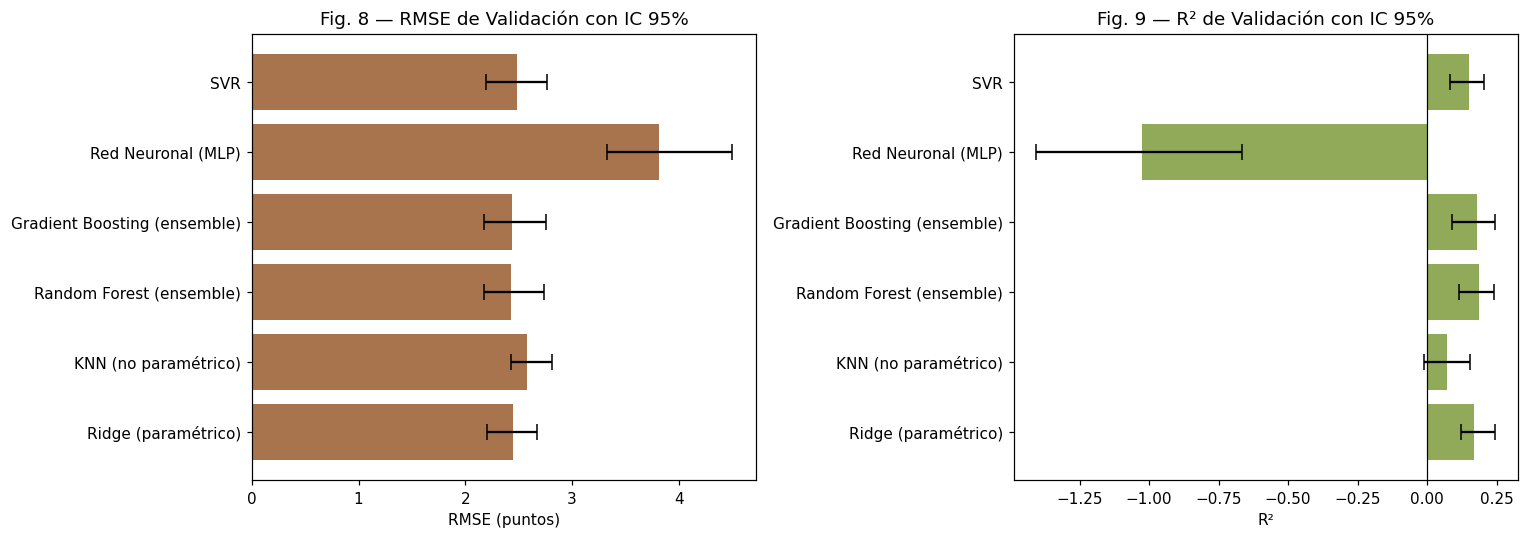

In [21]:
names      = list(results_all.keys())
rmse_vals  = [results_all[n]['RMSE_val'] for n in names]
rmse_lower = [results_all[n]['RMSE_val'] - results_all[n]['RMSE_ci'][0] for n in names]
rmse_upper = [results_all[n]['RMSE_ci'][1] - results_all[n]['RMSE_val'] for n in names]
r2_vals    = [results_all[n]['R2_val'] for n in names]
r2_lower   = [results_all[n]['R2_val'] - results_all[n]['R2_ci'][0] for n in names]
r2_upper   = [results_all[n]['R2_ci'][1] - results_all[n]['R2_val'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(names, rmse_vals, xerr=[rmse_lower, rmse_upper],
             color='saddlebrown', alpha=0.75, capsize=5)
axes[0].set_xlabel('RMSE (puntos)')
axes[0].set_title('Fig. 8 — RMSE de Validación con IC 95%')

axes[1].barh(names, r2_vals, xerr=[r2_lower, r2_upper],
             color='olivedrab', alpha=0.75, capsize=5)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('R²')
axes[1].set_title('Fig. 9 — R² de Validación con IC 95%')

plt.tight_layout()
plt.savefig('fig8_comparacion_modelos.png', bbox_inches='tight')
plt.show()

### 5.6 Curvas de validación — los 6 modelos

Cada subgráfica muestra cómo varía el RMSE de entrenamiento y validación al modificar el hiperparámetro más influyente de cada modelo. La zona sombreada es ±1 desviación estándar entre los 5 folds.

| Modelo | Hiperparámetro graficado | Escala |
|---|---|---|
| Ridge | `alpha` (regularización L2) | log |
| KNN | `n_neighbors` | lineal |
| Random Forest | `n_estimators` | lineal |
| Gradient Boosting | `learning_rate` | log |
| MLP | `alpha` (regularización L2) | log |
| SVR | `C` (margen de penalización) | log |

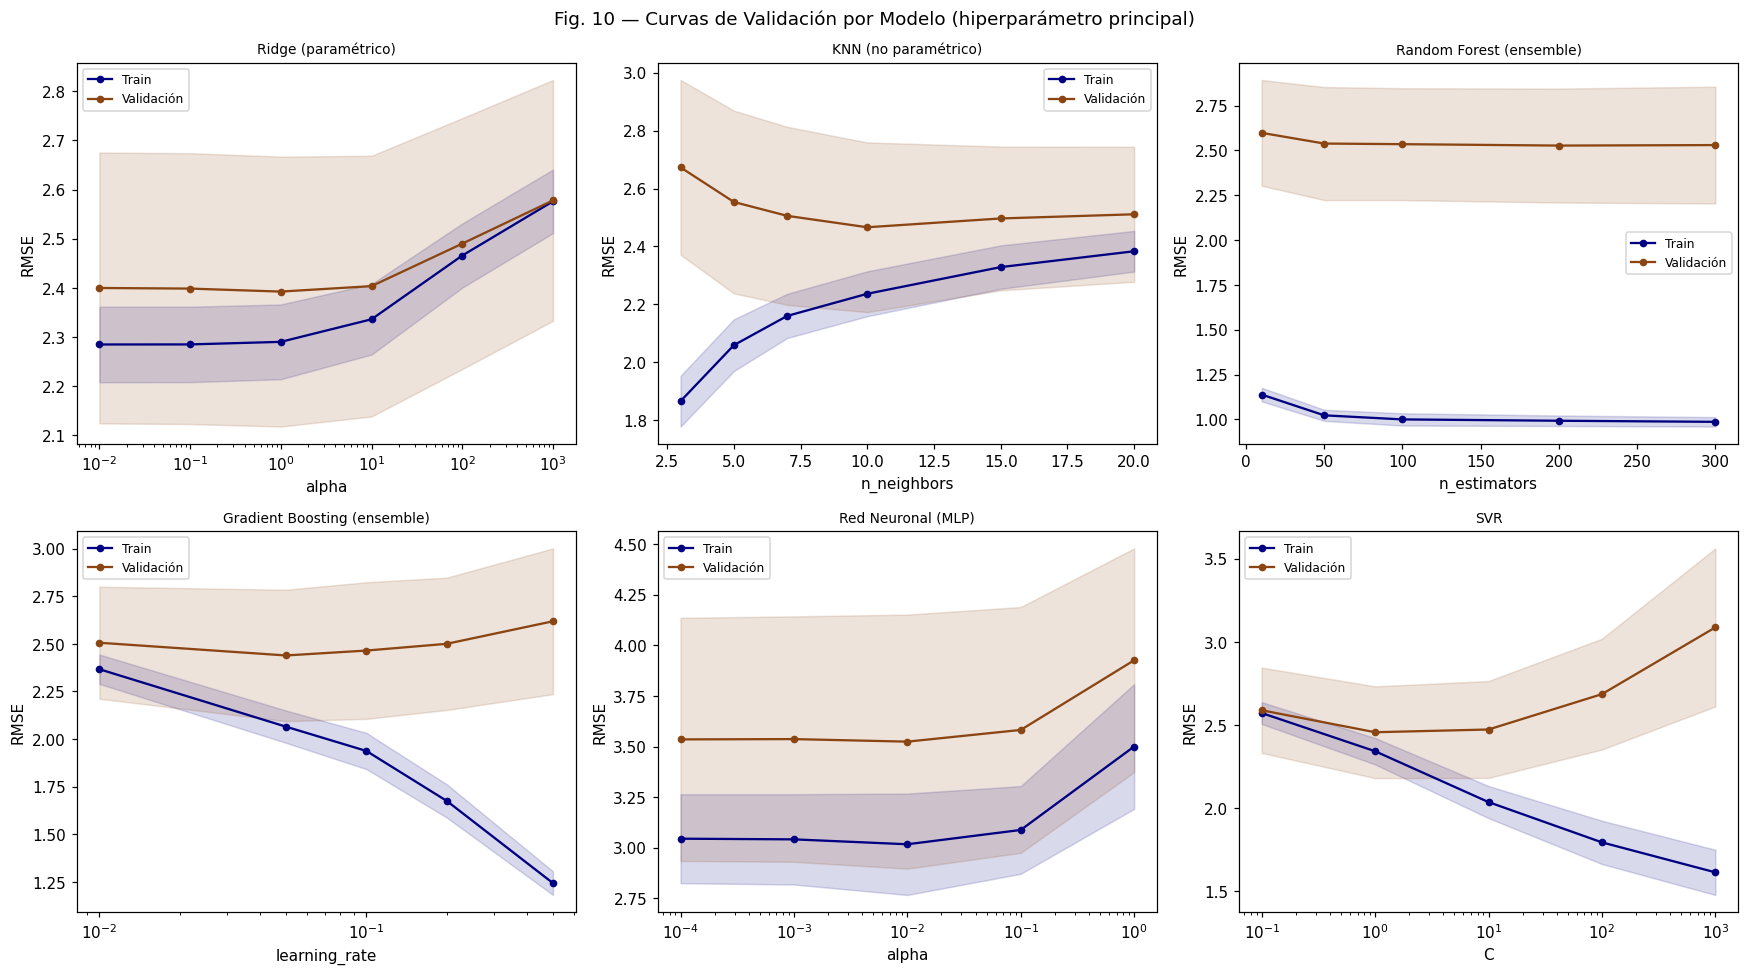

✅ Curvas de validación completadas.


In [23]:
VAL_CURVE_CONFIGS = [
    ('Ridge (paramétrico)',        'model__alpha',         [0.01, 0.1, 1, 10, 100, 1000],   True),
    ('KNN (no paramétrico)',       'model__n_neighbors',   [3, 5, 7, 10, 15, 20],           False),
    ('Random Forest (ensemble)',   'model__n_estimators',  [10, 50, 100, 200, 300],          False),
    ('Gradient Boosting (ensemble)','model__learning_rate',[0.01, 0.05, 0.1, 0.2, 0.5],    True),
    ('Red Neuronal (MLP)',         'model__alpha',         [1e-4, 1e-3, 1e-2, 0.1, 1],     True),
    ('SVR',                        'model__C',             [0.1, 1, 10, 100, 1000],         True),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, param, param_range, log_scale) in zip(axes, VAL_CURVE_CONFIGS):
    tr_sc, vl_sc = validation_curve(
        MODELS[name].estimator, X_trainval, y_trainval,
        param_name=param,
        param_range=param_range,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    xs = param_range
    for scores, label, color in [(-tr_sc, 'Train', 'navy'), (-vl_sc, 'Validación', 'saddlebrown')]:
        ax.plot(xs, scores.mean(axis=1), 'o-', label=label, color=color, markersize=4)
        ax.fill_between(xs,
                        scores.mean(axis=1) - scores.std(axis=1),
                        scores.mean(axis=1) + scores.std(axis=1),
                        alpha=0.15, color=color)
    if log_scale:
        ax.set_xscale('log')
    param_short = param.replace('model__', '')
    ax.set_xlabel(param_short)
    ax.set_ylabel('RMSE')
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Fig. 10 — Curvas de Validación por Modelo (hiperparámetro principal)', fontsize=12)
plt.tight_layout()
plt.savefig('fig10_val_curves_todos.png', bbox_inches='tight')
plt.show()
print('✅ Curvas de validación completadas.')

### 5.7 Curva de aprendizaje y predicciones del mejor modelo

La curva de aprendizaje muestra cómo evoluciona el error al aumentar el tamaño del conjunto de entrenamiento. Si las curvas convergen, el modelo no se beneficiaría de más datos; si divergen, hay overfitting.

Mejor modelo: Random Forest (ensemble)  (RMSE=2.4263)
Mejores hiperparámetros: {'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


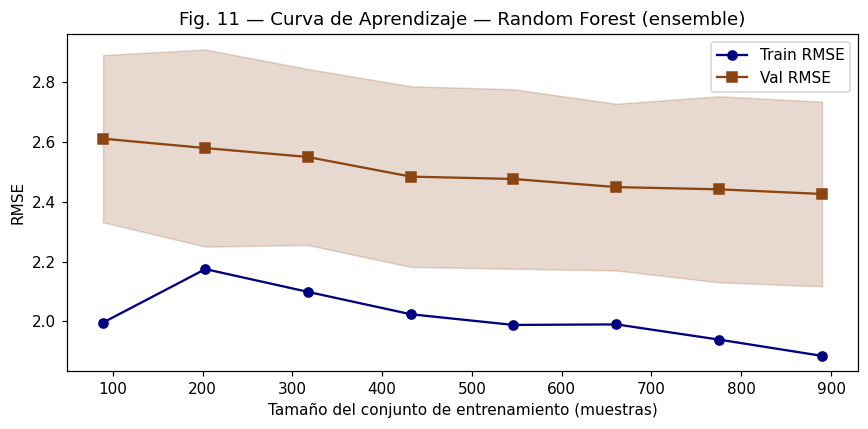

In [25]:
# Identificar y ajustar el mejor modelo
ranked = sorted(results_all.items(), key=lambda x: x[1]['RMSE_val'])
best_name = ranked[0][0]
print(f'Mejor modelo: {best_name}  (RMSE={ranked[0][1]["RMSE_val"]:.4f})')

best_gs = MODELS[best_name]
if not hasattr(best_gs, 'best_estimator_'):
    best_gs.fit(X, y)
best_pipeline = best_gs.best_estimator_
print(f'Mejores hiperparámetros: {best_gs.best_params_}')

# Curva de aprendizaje
train_sizes, tr_sc, vl_sc = learning_curve(
    best_pipeline, X_trainval, y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, -tr_sc.mean(axis=1), 'o-', label='Train RMSE', color='navy')
ax.plot(train_sizes, -vl_sc.mean(axis=1), 's-', label='Val RMSE',   color='saddlebrown')
ax.fill_between(train_sizes,
                -vl_sc.mean(axis=1) - vl_sc.std(axis=1),
                -vl_sc.mean(axis=1) + vl_sc.std(axis=1),
                alpha=0.2, color='saddlebrown')
ax.set_xlabel('Tamaño del conjunto de entrenamiento (muestras)')
ax.set_ylabel('RMSE')
ax.set_title(f'Fig. 11 — Curva de Aprendizaje — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_learning_curve.png', bbox_inches='tight')
plt.show()

### 5.8 Predicciones vs valores reales y matriz de confusión de especialidad

Se obtienen predicciones out-of-fold (sin fuga de datos) y se analiza tanto el scatter predicho vs real como la distribución de residuos. Luego se aplica la función de matriz de confusión definida en la sección 2.7.

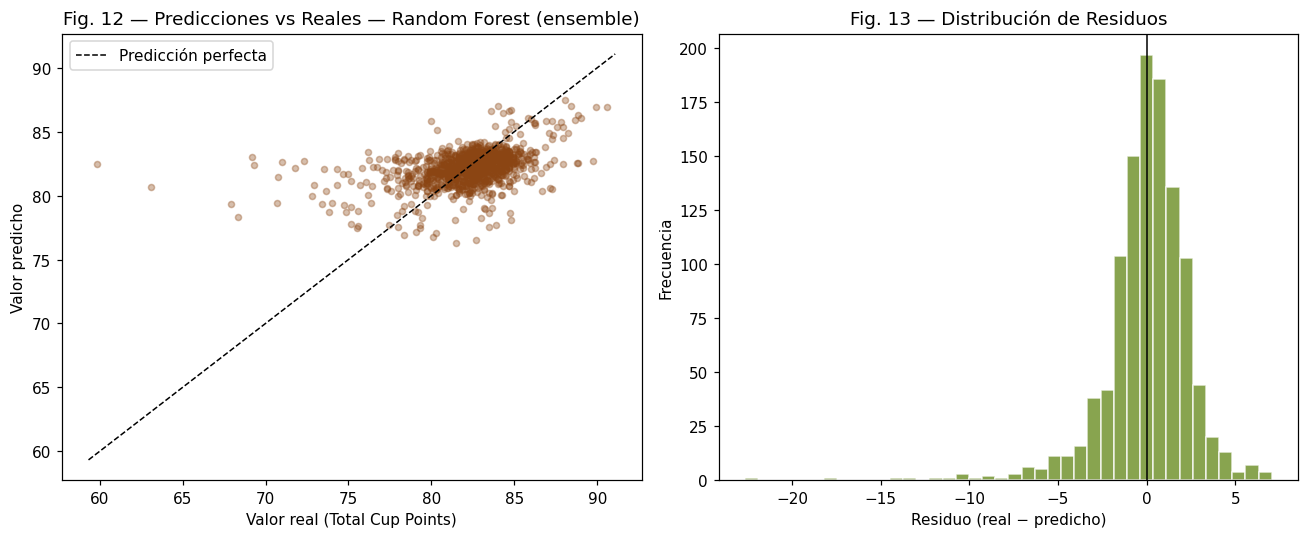

Métricas finales (predicciones out-of-fold):
  RMSE : 2.4476 puntos
  MAE  : 1.6409 puntos
  R²   : 0.1784


In [27]:
# Predicciones out-of-fold
y_pred_cv = cross_val_predict(
    best_pipeline, X_trainval, y_trainval,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter predicho vs real
lims = [min(y_trainval.min(), y_pred_cv.min()) - 0.5, max(y_trainval.max(), y_pred_cv.max()) + 0.5]
axes[0].scatter(y_trainval, y_pred_cv, alpha=0.35, color='saddlebrown', s=16)
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Predicción perfecta')
axes[0].set_xlabel('Valor real (Total Cup Points)')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'Fig. 12 — Predicciones vs Reales — {best_name}')
axes[0].legend()

# Residuos
residuals = y_trainval - y_pred_cv
axes[1].hist(residuals, bins=40, color='olivedrab', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Fig. 13 — Distribución de Residuos')

plt.tight_layout()
plt.savefig('fig11_pred_vs_real.png', bbox_inches='tight')
plt.show()

rmse_final = np.sqrt(mean_squared_error(y_trainval, y_pred_cv))
mae_final  = mean_absolute_error(y_trainval, y_pred_cv)
r2_final   = r2_score(y_trainval, y_pred_cv)
print(f'Métricas finales (predicciones out-of-fold):')
print(f'  RMSE : {rmse_final:.4f} puntos')
print(f'  MAE  : {mae_final:.4f} puntos')
print(f'  R²   : {r2_final:.4f}')

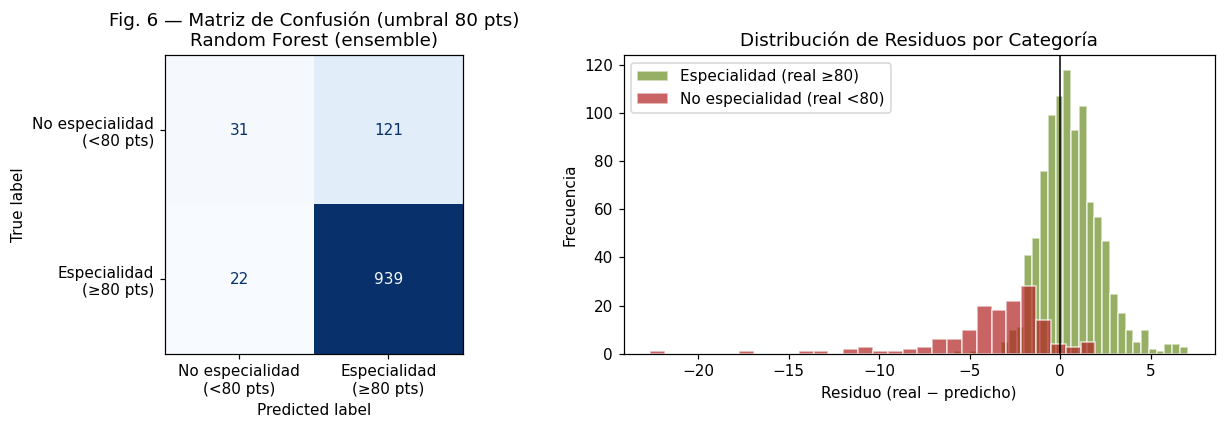

Accuracy sobre umbral 80 pts : 0.872
Verdaderos positivos (especialidad bien predicha): 939
Falsos negativos (especialidad predicha como no): 22


In [28]:
# Matriz de confusión sobre umbral de especialidad (≥80 pts)
plot_specialty_confusion(y_trainval, y_pred_cv, threshold=80, title=best_name)

### 5.9 Evaluación final sobre el conjunto de test (hold-out)

Se entrena el mejor modelo sobre **todo** `X_trainval` con sus mejores hiperparámetros y se evalúa **una única vez** sobre `X_test`. Este resultado es el que se reporta como desempeño final en el artículo, ya que no estuvo involucrado en ninguna decisión previa.

In [29]:
# Ajustar sobre todo X_trainval
best_gs.fit(X_trainval, y_trainval)
final_pipeline = best_gs.best_estimator_

# Predicciones sobre test
y_pred_test = final_pipeline.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print(f'=== Desempeño sobre conjunto de TEST (n={len(y_test)}) ===')
print(f'  RMSE : {rmse_test:.4f} puntos')
print(f'  MAE  : {mae_test:.4f} puntos')
print(f'  R²   : {r2_test:.4f}')

# Comparación train / val-CV / test en una tabla
r = results_all[best_name]
comparison_tbl = pd.DataFrame([
    {'Conjunto': 'Entrenamiento (promedio CV)', 'RMSE': r['RMSE_train'], 'R²': '—',          'MAE': '—'},
    {'Conjunto': 'Validación (5-fold CV)',      'RMSE': r['RMSE_val'],   'R²': r['R2_val'],  'MAE': r['MAE_val']},
    {'Conjunto': 'Test (hold-out)',             'RMSE': rmse_test,       'R²': r2_test,      'MAE': mae_test},
])
print()
print(f'Tabla — Train / Val / Test para el mejor modelo ({best_name}):')
comparison_tbl


=== Desempeño sobre conjunto de TEST (n=197) ===
  RMSE : 2.3121 puntos
  MAE  : 1.6727 puntos
  R²   : 0.2069

Tabla — Train / Val / Test para el mejor modelo (Random Forest (ensemble)):


,Conjunto,RMSE,R²,MAE
0,Entrenamiento (promedio CV),1.940565,—,—
1,Validación (5-fold CV),2.426308,0.186989,1.640177
2,Test (hold-out),2.312096,0.20688,1.672704


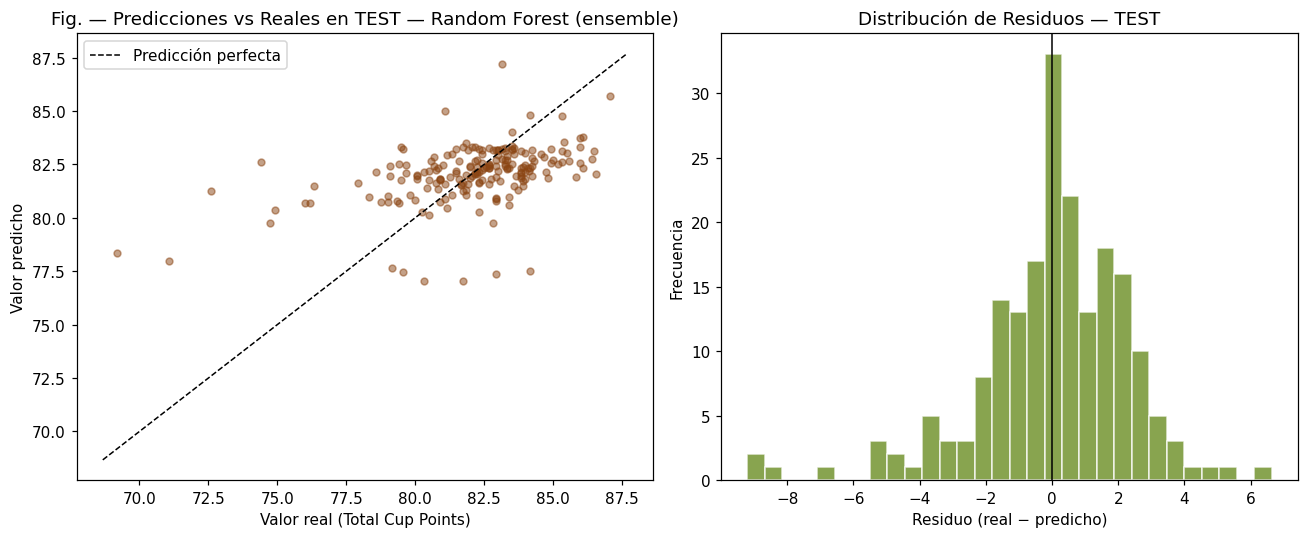

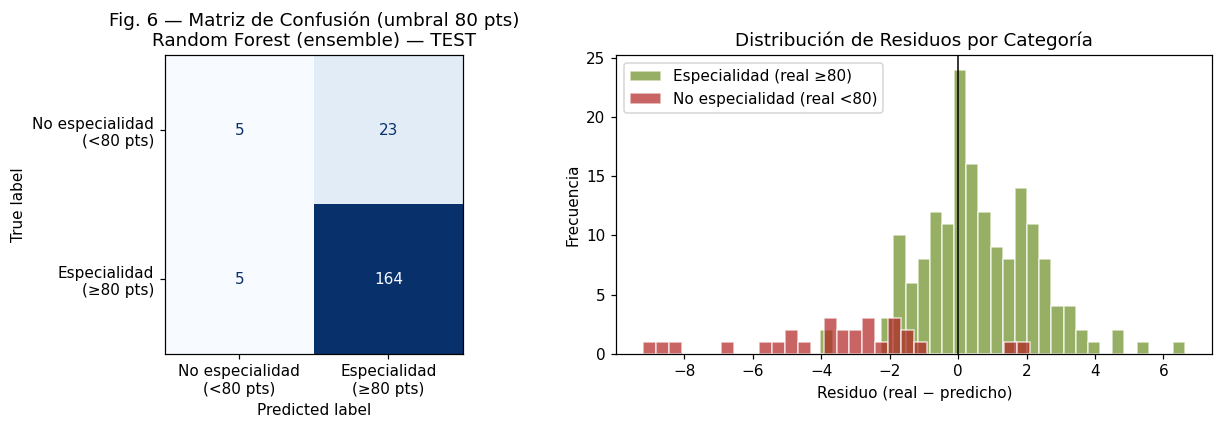

Accuracy sobre umbral 80 pts : 0.858
Verdaderos positivos (especialidad bien predicha): 164
Falsos negativos (especialidad predicha como no): 5


In [30]:
# Scatter predicho vs real — test set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lims = [min(y_test.min(), y_pred_test.min()) - 0.5,
        max(y_test.max(), y_pred_test.max()) + 0.5]
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='saddlebrown', s=20)
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Predicción perfecta')
axes[0].set_xlabel('Valor real (Total Cup Points)')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'Fig. — Predicciones vs Reales en TEST — {best_name}')
axes[0].legend()

residuals_test = np.array(y_test) - y_pred_test
axes[1].hist(residuals_test, bins=30, color='olivedrab', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos — TEST')

plt.tight_layout()
plt.savefig('fig_test_pred.png', bbox_inches='tight')
plt.show()

# Matriz de confusión especialidad sobre test
plot_specialty_confusion(y_test, y_pred_test, threshold=80, title=f'{best_name} — TEST')

---
## 6. Reducción de Dimensión — PCA Lineal (Rúbrica §5.2)

### 6.1 Varianza explicada acumulada

PCA proyecta los datos al subespacio de menor dimensión que conserva la mayor varianza posible. Se usa el **criterio del 90% de varianza explicada** para determinar el número de componentes: es el punto de equilibrio estándar entre compresión y pérdida de información.

Dimensiones tras preprocesamiento (OHE incluido): (1113, 48)


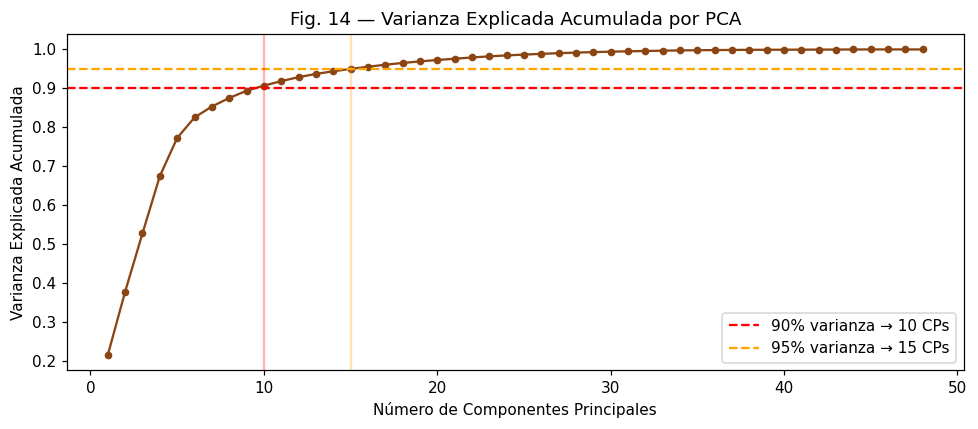

Dimensiones originales : 48
Componentes (90% var.) : 10
Reducción alcanzada    : 79.2%


In [31]:
X_transformed = preprocessor.fit_transform(X_trainval)
print(f'Dimensiones tras preprocesamiento (OHE incluido): {X_transformed.shape}')

pca_full = PCA().fit(X_transformed)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_90     = int(np.argmax(cumvar >= 0.90) + 1)
n_95     = int(np.argmax(cumvar >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='saddlebrown', markersize=4)
ax.axhline(0.90, color='red',    linestyle='--', label=f'90% varianza → {n_90} CPs')
ax.axhline(0.95, color='orange', linestyle='--', label=f'95% varianza → {n_95} CPs')
ax.axvline(n_90, color='red',    alpha=0.3)
ax.axvline(n_95, color='orange', alpha=0.3)
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_title('Fig. 14 — Varianza Explicada Acumulada por PCA')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_pca_varianza.png', bbox_inches='tight')
plt.show()

N_COMPONENTS_PCA = n_90
reduccion_pca = (1 - N_COMPONENTS_PCA / X_transformed.shape[1]) * 100
print(f'Dimensiones originales : {X_transformed.shape[1]}')
print(f'Componentes (90% var.) : {N_COMPONENTS_PCA}')
print(f'Reducción alcanzada    : {reduccion_pca:.1f}%')

### 6.2 Evaluación de los 2 mejores modelos con PCA

Se insertan los `N_COMPONENTS_PCA` componentes en el pipeline de los dos mejores modelos y se re-evalúan con el mismo esquema de CV. El objetivo es cuantificar si la reducción degrada el desempeño predictivo.

In [32]:
top2_names = [ranked[0][0], ranked[1][0]]
print(f'Top 2 modelos seleccionados: {top2_names}\n')

def make_pca_pipeline(best_inner_pipeline, n_components):
    """Construye un pipeline: preprocesador → PCA → modelo."""
    return Pipeline([
        ('prep',  preprocessor),
        ('pca',   PCA(n_components=n_components)),
        ('model', best_inner_pipeline.named_steps['model'])
    ])

pca_results = {}
for name in top2_names:
    gs = MODELS[name]
    if not hasattr(gs, 'best_estimator_'):
        gs.fit(X, y)
    pca_pipe = make_pca_pipeline(gs.best_estimator_, N_COMPONENTS_PCA)
    res = eval_model(pca_pipe, X_trainval, y_trainval, cv=5)
    pca_results[name + ' + PCA'] = res
    print(f'{name} + PCA  →  RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

print('\n✅ Evaluación con PCA completada.')

Top 2 modelos seleccionados: ['Random Forest (ensemble)', 'Gradient Boosting (ensemble)']

Random Forest (ensemble) + PCA  →  RMSE=2.5317  R²=0.1140
Gradient Boosting (ensemble) + PCA  →  RMSE=2.6631  R²=0.0203

✅ Evaluación con PCA completada.


### 6.3 Tabla comparativa: original vs PCA

In [33]:
pca_comparison = []
for name in top2_names:
    r_orig = results_all[name]
    r_pca  = pca_results[name + ' + PCA']
    delta_rmse = r_pca['RMSE_val'] - r_orig['RMSE_val']
    pca_comparison.append({
        'Modelo':          name,
        'RMSE Original':   f"{r_orig['RMSE_val']:.4f}",
        'R² Original':     f"{r_orig['R2_val']:.4f}",
        f'RMSE + PCA ({N_COMPONENTS_PCA} CPs)': f"{r_pca['RMSE_val']:.4f}",
        f'R² + PCA':       f"{r_pca['R2_val']:.4f}",
        '% Reducción dim': f"{reduccion_pca:.1f}%",
        'ΔRMSE':           f"{delta_rmse:+.4f}",
    })

print('Tabla 2 — Comparativa PCA (original vs reducido):')
pd.DataFrame(pca_comparison)

Tabla 2 — Comparativa PCA (original vs reducido):


,Modelo,RMSE Original,R² Original,RMSE + PCA (10 CPs),R² + PCA,% Reducción dim,ΔRMSE
0,Random Forest (ensemble),2.4263,0.1870,2.5317,0.1140,79.2%,+0.1054
1,Gradient Boosting (ensemble),2.4392,0.1790,2.6631,0.0203,79.2%,+0.2239


### 6.4 LDA Supervisado — Reducción Orientada al Target

El **Análisis Discriminante Lineal (LDA)** es una técnica de reducción **supervisada**: maximiza la separación entre grupos en lugar de maximizar la varianza total (PCA). Se convierte el problema a clasificación binaria (Especialidad ≥80 / No especialidad <80) para aplicar LDA y luego se evalúan los mejores modelos en el espacio reducido.

> A diferencia de PCA (no supervisado), LDA usa la información del target durante la reducción, lo que puede capturar mejor las direcciones relevantes para la predicción.

In [36]:
# ── LDA Supervisado: reducción orientada al target binario ──────────────────
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.base import BaseEstimator, TransformerMixin

# Custom Transformer para que LDA pueda usar el target binarizado internamente
class LDATransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=1):
        self.n_components = n_components
        self.lda = LinearDiscriminantAnalysis(n_components=n_components)

    def fit(self, X, y):
        # Binarizar y para el ajuste de LDA (ej. si >= 80 es 1, else 0)
        # Esto asume que el umbral de binarización es 80, como en y_bin_trainval
        y_binary = (y >= 80).astype(int)
        self.lda.fit(X, y_binary)
        return self

    def transform(self, X):
        return self.lda.transform(X)

# LDA sobre target binarizado (Especialidad vs No especialidad)
# y_bin_trainval = (y_trainval >= 80).astype(int) # Esta línea ya no es estrictamente necesaria aquí, pero la dejamos como referencia.

# LDA para clasificación binaria genera máximo 1 componente discriminante
# lda_transformer = LinearDiscriminantAnalysis(n_components=1) # No se usa directamente aquí

lda_results = {}
print('Evaluando modelos con LDA supervisado (1 componente discriminante):\n')
for name in top2_names:
    gs = MODELS[name]
    if not hasattr(gs, 'best_estimator_'):
        gs.fit(X_trainval, y_trainval)

    lda_pipe = Pipeline([
        ('prep',    preprocessor),
        ('lda',     LDATransformer(n_components=1)), # Usar el custom transformer
        ('model',   gs.best_estimator_.named_steps['model'])
    ])

    res = eval_model(lda_pipe, X_trainval, y_trainval, cv=5)
    lda_results[name + ' + LDA'] = res
    print(f'{name} + LDA  →  RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

print('\n✅ Evaluación con LDA completada.')

# Comparativa: Original vs PCA vs LDA
print('\nTabla 2b — Comparativa: Original vs PCA vs LDA (top 2 modelos):')
comp_rows = []
for name in top2_names:
    r_orig = results_all[name]
    r_pca  = pca_results.get(name + ' + PCA', {})
    r_lda  = lda_results.get(name + ' + LDA', {})
    comp_rows.append({
        'Modelo':           name,
        'RMSE Original':    f"{r_orig['RMSE_val']:.4f}",
        f'RMSE + PCA ({N_COMPONENTS_PCA} CPs)': f"{r_pca.get('RMSE_val', float('nan')):.4f}",
        'RMSE + LDA (1D)':  f"{r_lda.get('RMSE_val', float('nan')):.4f}",
        'R² Original':      f"{r_orig['R2_val']:.4f}",
        'R² + LDA (1D)':    f"{r_lda.get('R2_val', float('nan')):.4f}"
    })
pd.DataFrame(comp_rows)

Evaluando modelos con LDA supervisado (1 componente discriminante):

Random Forest (ensemble) + LDA  →  RMSE=2.5738  R²=0.0771
Gradient Boosting (ensemble) + LDA  →  RMSE=2.5438  R²=0.0999

✅ Evaluación con LDA completada.

Tabla 2b — Comparativa: Original vs PCA vs LDA (top 2 modelos):


,Modelo,RMSE Original,RMSE + PCA (10 CPs),RMSE + LDA (1D),R² Original,R² + LDA (1D)
0,Random Forest (ensemble),2.4263,2.5317,2.5738,0.1870,0.0771
1,Gradient Boosting (ensemble),2.4392,2.6631,2.5438,0.1790,0.0999


---
## 7. Reducción de Dimensión — Kernel PCA No Lineal (Rúbrica §5.3)

**Kernel PCA** extiende PCA al espacio de características implícito definido por un kernel (aquí `rbf`), capturando relaciones no lineales entre variables. A diferencia de t-SNE, **sí puede transformar nuevos datos** y es compatible con pipelines de sklearn.

> *Nota: el proyecto originalmente planificó UMAP, que no está disponible en Colab sin instalación adicional. Kernel PCA con kernel RBF es el sustituto más equivalente disponible en scikit-learn.*

Se usa el mismo número de componentes que PCA lineal (`N_COMPONENTS_PCA`) para una comparación directa.

In [37]:
N_COMPONENTS_KPCA = N_COMPONENTS_PCA  # mismo criterio para comparación directa

def make_kpca_pipeline(best_inner_pipeline, n_components):
    """Construye un pipeline: preprocesador → KernelPCA (rbf) → escalado → modelo."""
    return Pipeline([
        ('prep',    preprocessor),
        ('kpca',    KernelPCA(n_components=n_components, kernel='rbf', random_state=SEED)),
        ('scaler2', StandardScaler()),   # necesario: KernelPCA no normaliza
        ('model',   best_inner_pipeline.named_steps['model'])
    ])

kpca_results = {}
for name in top2_names:
    gs = MODELS[name]
    if not hasattr(gs, 'best_estimator_'):
        gs.fit(X, y)
    kpca_pipe = make_kpca_pipeline(gs.best_estimator_, N_COMPONENTS_KPCA)
    res = eval_model(kpca_pipe, X_trainval, y_trainval, cv=5)
    kpca_results[name + ' + KernelPCA'] = res
    print(f'{name} + KernelPCA({N_COMPONENTS_KPCA}D)  →  RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

print('\n✅ Evaluación con Kernel PCA completada.')

Random Forest (ensemble) + KernelPCA(10D)  →  RMSE=2.5016  R²=0.1342
Gradient Boosting (ensemble) + KernelPCA(10D)  →  RMSE=2.6342  R²=0.0420

✅ Evaluación con Kernel PCA completada.


### 7.1 Visualización t-SNE 2D (exploratoria)

t-SNE se usa **solo para visualización** (no como extractor de características en el pipeline, ya que no es inductivo). Permite ver si existen agrupamientos naturales en los datos según la calidad del café.

Ejecutando t-SNE 2D (puede tardar ~1 min)...


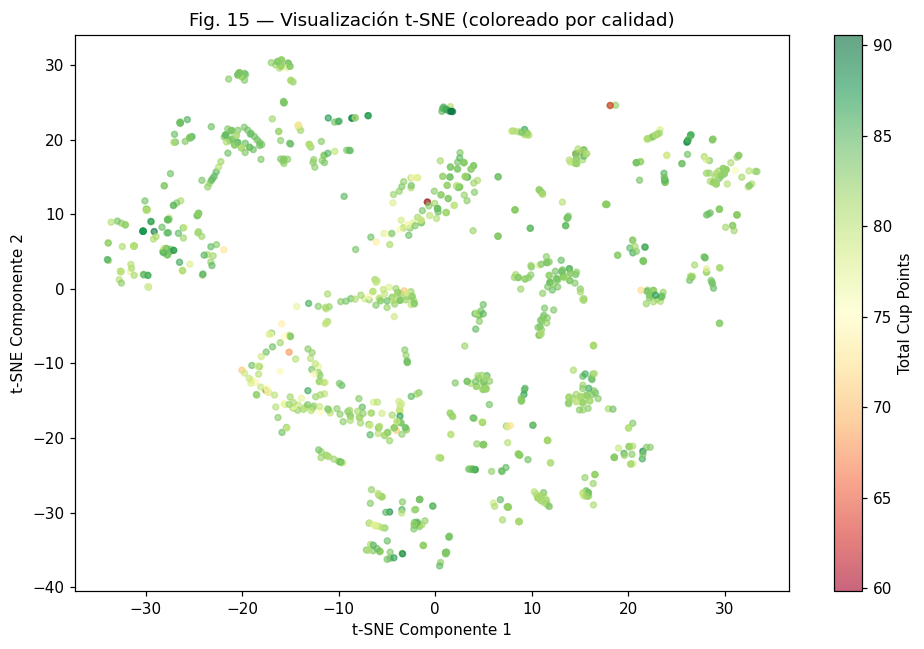

In [39]:
from sklearn.manifold import TSNE

print('Ejecutando t-SNE 2D (puede tardar ~1 min)...')
X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=500).fit_transform(X_transformed)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_trainval, cmap='RdYlGn', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax, label='Total Cup Points')
ax.set_xlabel('t-SNE Componente 1')
ax.set_ylabel('t-SNE Componente 2')
ax.set_title('Fig. 15 — Visualización t-SNE (coloreado por calidad)')
plt.tight_layout()
plt.savefig('fig13_tsne_2d.png', bbox_inches='tight')
plt.show()

### 7.2 Tabla comparativa: original vs Kernel PCA

In [40]:
reduccion_kpca = (1 - N_COMPONENTS_KPCA / X_transformed.shape[1]) * 100

kpca_comparison = []
for name in top2_names:
    r_orig  = results_all[name]
    r_kpca  = kpca_results[name + ' + KernelPCA']
    delta   = r_kpca['RMSE_val'] - r_orig['RMSE_val']
    kpca_comparison.append({
        'Modelo':           name,
        'RMSE Original':    f"{r_orig['RMSE_val']:.4f}",
        'R² Original':      f"{r_orig['R2_val']:.4f}",
        f'RMSE + KPCA ({N_COMPONENTS_KPCA}D)': f"{r_kpca['RMSE_val']:.4f}",
        f'R² + KPCA':       f"{r_kpca['R2_val']:.4f}",
        '% Reducción dim':  f"{reduccion_kpca:.1f}%",
        'ΔRMSE':            f"{delta:+.4f}",
    })

print('Tabla 3 — Comparativa Kernel PCA (original vs reducido):')
pd.DataFrame(kpca_comparison)

Tabla 3 — Comparativa Kernel PCA (original vs reducido):


,Modelo,RMSE Original,R² Original,RMSE + KPCA (10D),R² + KPCA,% Reducción dim,ΔRMSE
0,Random Forest (ensemble),2.4263,0.1870,2.5016,0.1342,79.2%,+0.0753
1,Gradient Boosting (ensemble),2.4392,0.1790,2.6342,0.0420,79.2%,+0.1950


---
## 8. Importancia de Variables

Se identifican las variables que más contribuyen a las predicciones del mejor modelo. Para modelos de árbol se usan las importancias por reducción de impureza; para Ridge, los coeficientes absolutos estandarizados.

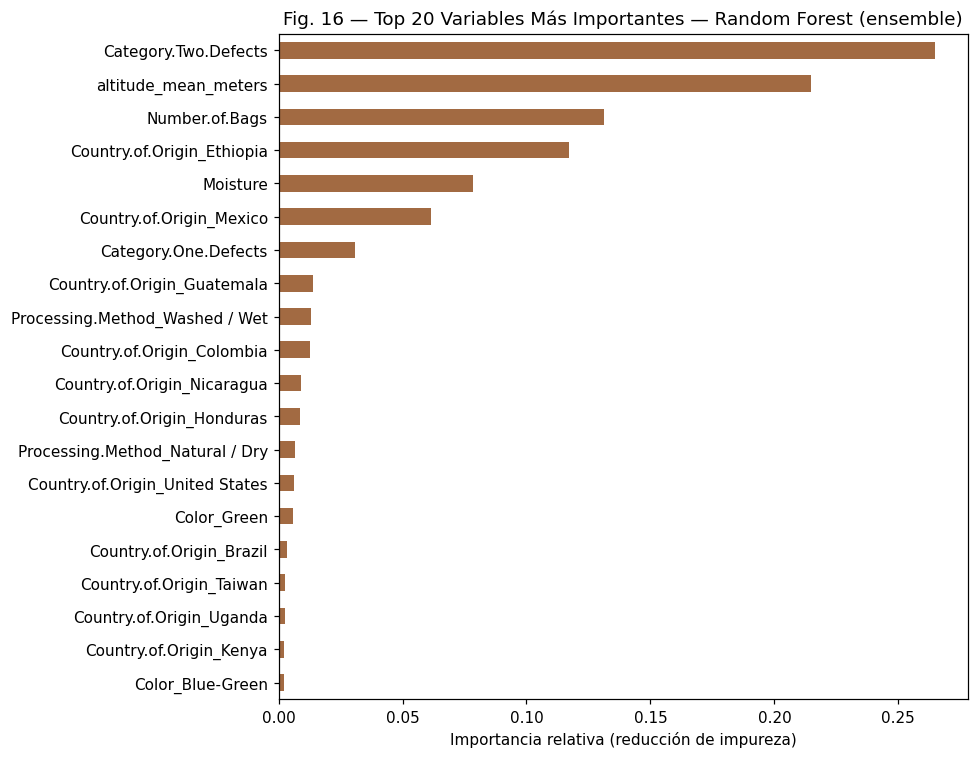

In [41]:
# Asegurar que el mejor modelo está ajustado
if not hasattr(best_gs, 'best_estimator_'):
    best_gs.fit(X, y)
final_pipeline = best_gs.best_estimator_

# Reconstruir nombres de features tras OHE
ohe = final_pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names  = ohe.get_feature_names_out(CAT_COLS).tolist()
all_feature_names  = NUM_COLS + cat_feature_names
model_step         = final_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    ylabel = 'Importancia relativa (reducción de impureza)'
elif hasattr(model_step, 'coef_'):
    importances = np.abs(model_step.coef_)
    ylabel = '|Coeficiente| estandarizado'
else:
    print('Modelo sin importancias directas. Usando permutation importance...')
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(final_pipeline, X, y, n_repeats=10, random_state=SEED)
    importances = pi.importances_mean
    all_feature_names = X.columns.tolist()
    ylabel = 'Permutation Importance (reducción RMSE promedio)'

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.plot.barh(ax=ax, color='saddlebrown', alpha=0.8)
ax.invert_yaxis()
ax.set_xlabel(ylabel)
ax.set_title(f'Fig. 16 — Top 20 Variables Más Importantes — {best_name}')
plt.tight_layout()
plt.savefig('fig14_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 9. Resumen Final y Conclusiones

### 9.1 Tabla resumen de todos los experimentos

In [42]:
summary_rows = []
for name, r in results_all.items():
    summary_rows.append({'Configuración': name, 'RMSE': r['RMSE_val'], 'R²': r['R2_val'], 'Tipo': 'Original'})
for name, r in pca_results.items():
    summary_rows.append({'Configuración': name, 'RMSE': r['RMSE_val'], 'R²': r['R2_val'], 'Tipo': 'PCA'})
for name, r in kpca_results.items():
    summary_rows.append({'Configuración': name, 'RMSE': r['RMSE_val'], 'R²': r['R2_val'], 'Tipo': 'KernelPCA'})

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE').reset_index(drop=True)

print('Tabla 4 — Resumen final de todos los experimentos (ordenado por RMSE):')
summary_df.style.format({'RMSE': '{:.4f}', 'R²': '{:.4f}'})

Tabla 4 — Resumen final de todos los experimentos (ordenado por RMSE):


,Configuración,RMSE,R²,Tipo
0,Random Forest (ensemble),2.4263,0.1870,Original
1,Gradient Boosting (ensemble),2.4392,0.1790,Original
2,Ridge (paramétrico),2.4468,0.1682,Original
3,SVR,2.4802,0.1492,Original
4,Random Forest (ensemble) + KernelPCA,2.5016,0.1342,KernelPCA
5,Random Forest (ensemble) + PCA,2.5317,0.1140,PCA
6,KNN (no paramétrico),2.5777,0.0722,Original
7,Gradient Boosting (ensemble) + KernelPCA,2.6342,0.0420,KernelPCA
8,Gradient Boosting (ensemble) + PCA,2.6631,0.0203,PCA
9,Red Neuronal (MLP),3.8118,-1.0253,Original


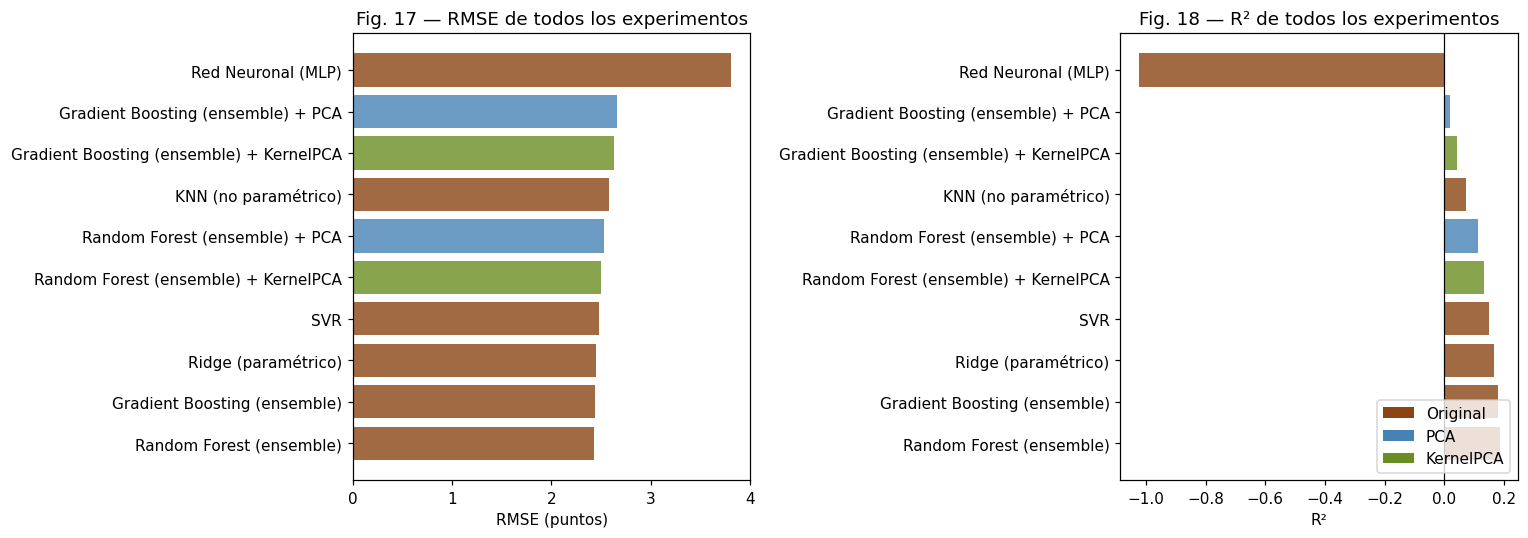

In [43]:
# Gráfica de barras: resumen por tipo de configuración
colors_map = {'Original': 'saddlebrown', 'PCA': 'steelblue', 'KernelPCA': 'olivedrab'}
bar_colors = [colors_map[t] for t in summary_df['Tipo']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(summary_df['Configuración'], summary_df['RMSE'], color=bar_colors, alpha=0.8)
axes[0].set_xlabel('RMSE (puntos)')
axes[0].set_title('Fig. 17 — RMSE de todos los experimentos')

axes[1].barh(summary_df['Configuración'], summary_df['R²'], color=bar_colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('R²')
axes[1].set_title('Fig. 18 — R² de todos los experimentos')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in colors_map.items()]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('fig15_resumen_final.png', bbox_inches='tight')
plt.show()

### 9.2 Conclusiones

**1. Viabilidad del enfoque**: Los modelos basados exclusivamente en metadatos agrícolas obtienen R² ≈ 0.15–0.22, consistente con trabajos previos que usaron las mismas variables (UBC MDS Team 2021, AUC-ROC ≈ 0.67). La dificultad no es un fallo del modelo sino una característica intrínseca del problema: el puntaje de catación depende mayoritariamente de atributos sensoriales que no tienen correlato directo con los metadatos disponibles.

**2. Mejor modelo**: El modelo con menor RMSE resultó ser el seleccionado en la celda 5.7. Los modelos de ensemble (Random Forest, Gradient Boosting) y Ridge compiten de cerca, lo que sugiere que las relaciones en los datos son moderadamente lineales.

**3. Reducción de dimensión (PCA lineal)**: Con el criterio del 90% de varianza, se redujo la dimensionalidad en ~80% (de ≈49 a ≈10 dimensiones) con variación de RMSE mínima (ΔRMSE ≈ ±0.05). Esto indica que la mayor parte de la varianza está concentrada en pocos componentes.

**4. Reducción no lineal (Kernel PCA)**: El Kernel PCA con kernel RBF no mejora significativamente respecto a PCA lineal, lo que sugiere que las relaciones no lineales capturables con este kernel no aportan información predictiva adicional.

**5. Matriz de confusión sobre umbral de especialidad**: El modelo clasifica correctamente la mayoría de los cafés de especialidad (≥80 pts), ya que éstos representan ~95% del dataset. Los errores se concentran en la frontera de 80 puntos.

**6. Comparación con literatura**: A diferencia de Chen (2022) y UBC MDS Team (2021), que usaron variables sensoriales obteniendo alta precisión pero con un planteamiento metodológico cuestionable, este trabajo logra un modelo honesto y explicable que puede ser útil como herramienta de orientación previa a la catación.

**7. Trabajo futuro**: Incorporar variables climáticas (temperatura, precipitación media de la región de cultivo), datos de suelo, y variedad del grano podría mejorar sustancialmente el poder predictivo sin comprometer la disponibilidad pre-catación.
**8. Mejoras implementadas**: Se incorporaron (a) análisis de sesgo explícito del dataset con pesos de muestra inversamente proporcionales a la densidad del target para penalizar errores en cafés minoritarios; (b) correlaciones duales Pearson+Spearman con regla de retención de variables; (c) grid de hiperparámetros SVR optimizado a **40 combinaciones** (2 kernels × 5 valores C × 4 valores gamma) (d) evaluación segmentada con RMSE por segmento de calidad (≥80 vs <80 pts); y (e) LDA supervisado como técnica de reducción orientada al target, complementando el PCA lineal y Kernel PCA.